# 8. Modern Convolutional Neural Networks

Now that we understand the basics of wiring together CNNs, let’s take a tour of modern CNN architectures. This tour is, by necessity, incomplete, thanks to the plethora of exciting new designs being added. Their importance derives from the fact that not only can they be used directly for vision tasks, but they also serve as basic feature generators for more advanced tasks such as tracking (Zhang et al., 2021), segmentation (Long et al., 2015), object detection (Redmon and Farhadi, 2018), or style transformation (Gatys et al., 2016). In this chapter, most sections correspond to a significant CNN architecture that was at some point (or currently) the base model upon which many research projects and deployed systems were built. Each of these networks was briefly a dominant architecture and many were winners or runners-up in the ImageNet competition which has served as a barometer of progress on supervised learning in computer vision since 2010. It is only recently that Transformers have begun to displace CNNs, starting with Dosovitskiy et al. (2021) and followed by the Swin Transformer (Liu et al., 2021). We will cover this development later in Section 11.

While the idea of *deep* neural networks is quite simple (stack together a bunch of layers), performance can vary wildly across architectures and hyperparameter choices. The neural networks described in this chapter are the product of intuition, a few mathematical insights, and a lot of trial and error. We present these models in chronological order, partly to convey a sense of the history so that you can form your own intuitions about where the field is heading and perhaps develop your own architectures. For instance, batch normalization and residual connections described in this chapter have offered two popular ideas for training and designing deep models, both of which have since also been applied to architectures beyond computer vision.

We begin our tour of modern CNNs with AlexNet (Krizhevsky et al., 2012), the first large-scale network deployed to beat conventional computer vision methods on a large-scale vision challenge; the VGG network (Simonyan and Zisserman, 2014), which makes use of a number of repeating blocks of elements; the network in network (NiN) that convolves whole neural networks patch-wise over inputs (Lin et al., 2013); GoogLeNet that uses networks with multi-branch convolutions (Szegedy et al., 2015); the residual network (ResNet) (He et al., 2016), which remains one of the most popular off-the-shelf architectures in computer vision; ResNeXt blocks (Xie et al., 2017) for sparser connections; and DenseNet (Huang et al., 2017) for a generalization of the residual architecture. Over time many special optimizations for efficient networks have been developed, such as coordinate shifts (ShiftNet) (Wu et al., 2018). This culminated in the automatic search for efficient architectures such as MobileNet v3 (Howard et al., 2019). It also includes the semi-automatic design exploration of Radosavovic et al. (2020) that led to the RegNetX/Y which we will discuss later in this chapter. The work is instructive insofar as it offers a path for marrying brute force computation with the ingenuity of an experimenter in the search for efficient design spaces. Of note is also the work of Liu et al. (2022) as it shows that training techniques (e.g., optimizers, data augmentation, and regularization) play a pivotal role in improving accuracy. It also shows that long-held assumptions, such as the size of a convolution window, may need to be revisited, given the increase in computation and data. We will cover this and many more questions in due course throughout this chapter.

## 8.1. Deep Convolutional Neural Networks (AlexNet)

Although CNNs were well known in the computer vision and machine learning communities following the introduction of LeNet (LeCun et al., 1995), they did not immediately dominate the field. Although LeNet achieved good results on early small datasets, the performance and feasibility of training CNNs on larger, more realistic datasets had yet to be established. In fact, for much of the intervening time between the early 1990s and the watershed results of 2012 (Krizhevsky et al., 2012), neural networks were often surpassed by other machine learning methods, such as kernel methods (Schölkopf and Smola, 2002), ensemble methods (Freund and Schapire, 1996), and structured estimation (Taskar et al., 2004).

For computer vision, this comparison is perhaps not entirely accurate. That is, although the inputs to convolutional networks consist of raw or lightly-processed (e.g., by centering) pixel values, practitioners would never feed raw pixels into traditional models. Instead, typical computer vision pipelines consisted of manually engineering feature extraction pipelines, such as SIFT (Lowe, 2004), SURF (Bay et al., 2006), and bags of visual words (Sivic and Zisserman, 2003). Rather than *learning* the features, the features were *crafted*. Most of the progress came from having more clever ideas for feature extraction on the one hand and deep insight into geometry (Hartley and Zisserman, 2000) on the other. The learning algorithm was often considered an afterthought.

Although some neural network accelerators were available in the 1990s, they were not yet sufficiently powerful to make deep multichannel, multilayer CNNs with a large number of parameters. For instance, NVIDIA's GeForce 256 from 1999 was able to process at most 480 million floating-point operations, such as additions and multiplications, per second (MFLOPS), without any meaningful programming framework for operations beyond games. Today's accelerators are able to perform in excess of 1000 TFLOPs per device. Moreover, datasets were still relatively small: OCR on 60,000 low-resolution $28 \times 28$ pixel images was considered a highly challenging task. Added to these obstacles, key tricks for training neural networks including parameter initialization heuristics (Glorot and Bengio, 2010), clever variants of stochastic gradient descent (Kingma and Ba, 2014), non-squashing activation functions (Nair and Hinton, 2010), and effective regularization techniques (Srivastava et al., 2014) were still missing.

Thus, rather than training *end-to-end* (pixel to classification) systems, classical pipelines looked more like this:

1. Obtain an interesting dataset. In the early days, these datasets required expensive sensors.

1. Preprocess the dataset with hand-crafted features based on some knowledge of optics, geometry, other analytic tools, and occasionally on the serendipitous discoveries by lucky graduate students.

1. Feed the data through a standard set of feature extractors such as the SIFT (scale-invariant feature transform) (Lowe, 2004), the SURF (speeded up robust features) (Bay et al., 2006), or any number of other hand-tuned pipelines. OpenCV still provides SIFT extractors to this day!

1. Dump the resulting representations into your favorite classifier, likely a linear model or kernel method, to train a classifier.

If you spoke to machine learning researchers, they would reply that machine learning was both important and beautiful. Elegant theories proved the properties of various classifiers (Boucheron et al., 2005) and convex optimization (Boyd and Vandenberghe, 2004) had become the mainstay for obtaining them. The field of machine learning was thriving, rigorous, and eminently useful. However, if you spoke to a computer vision researcher, you would hear a very different story. The dirty truth of image recognition, they would tell you, is that features, geometry (Hartley and Zisserman, 2000, Hartley and Kahl, 2009), and engineering, rather than novel learning algorithms, drove progress. Computer vision researchers justifiably believed that a slightly bigger or cleaner dataset or a slightly improved feature-extraction pipeline mattered far more to the final accuracy than any learning algorithm.

---

牧之：从相同的输入输出角度，网络是在代替多年积累下来的人工特征工程方法，转而通过数据集，让网络进行表征学习，并对比两者端到端的性能。这里的前提是，网络的前几层，确实有表征学习的能力，而且确实会自然而然地学习表征。

---

牧之：为什么网络的前几层会学习表征，后几层才是针对具体任务的功能？为什么会有这种现象？

---

牧之：你只是解释了现象，但没有解释出现这个现象的原因。

In [2]:
from torch import nn
from d2l import torch as d2l

### 8.1.1. Representation Learning

Another way to cast the state of affairs is that the most important part of the pipeline was the representation. And up until 2012 the representation was calculated mostly mechanically. In fact, engineering a new set of feature functions, improving results, and writing up the method all featured prominently in papers. SIFT (Lowe, 2004), SURF (Bay et al., 2006), HOG (histograms of oriented gradient) (Dalal and Triggs, 2005), bags of visual words (Sivic and Zisserman, 2003), and similar feature extractors ruled the roost.

Another group of researchers, including Yann LeCun, Geoff Hinton, Yoshua Bengio, Andrew Ng, Shun-ichi Amari, and Juergen Schmidhuber, had different plans. They believed that features themselves ought to be learned. Moreover, they believed that to be reasonably complex, the features ought to be hierarchically composed with multiple jointly learned layers, each with learnable parameters. In the case of an image, the lowest layers might come to detect edges, colors, and textures, by analogy with how the visual system in animals processes its input. In particular, the automatic design of visual features such as those obtained by sparse coding (Olshausen and Field, 1996) remained an open challenge until the advent of modern CNNs. It was not until Dean et al. (2012), Le (2013) that the idea of generating features from image data automatically gained significant traction.

The first modern CNN (Krizhevsky et al., 2012), named *AlexNet* after one of its inventors, Alex Krizhevsky, is largely an evolutionary improvement over LeNet. It achieved excellent performance in the 2012 ImageNet challenge.

<p align="center">
  <img src="https://d2l.ai/_images/filters.png"/>
  <br />
  <em>Fig. 8.1.1</em> Image filters learned by the first layer of AlexNet. Reproduction courtesy of Krizhevsky et al. (2012).
</p>

Interestingly, in the lowest layers of the network, the model learned feature extractors that resembled some traditional filters. Fig. 8.1.1 shows lower-level image descriptors. Higher layers in the network might build upon these representations to represent larger structures, like eyes, noses, blades of grass, and so on. Even higher layers might represent whole objects like people, airplanes, dogs, or frisbees. Ultimately, the final hidden state learns a compact representation of the image that summarizes its contents such that data belonging to different categories can be easily separated.

AlexNet (2012) and its precursor LeNet (1995) share many architectural elements. This begs the question: why did it take so long? A key difference was that, over the previous two decades, the amount of data and the computing power available had increased significantly. As such AlexNet was much larger: it was trained on much more data, and on much faster GPUs compared to the CPUs available in 1995.

#### 8.1.1.1. Missing Ingredient: Data

Deep models with many layers require large amounts of data in order to enter the regime where they significantly outperform traditional methods based on convex optimizations (e.g., linear and kernel methods). However, given the limited storage capacity of computers, the relative expense of (imaging) sensors, and the comparatively tighter research budgets in the 1990s, most research relied on tiny datasets. Numerous papers relied on the UCI collection of datasets, many of which contained only hundreds or (a few) thousands of images captured in low resolution and often with an artificially clean background.

In 2009, the ImageNet dataset was released (Deng et al., 2009), challenging researchers to learn models from 1 million examples, 1000 each from 1000 distinct categories of objects. The categories themselves were based on the most popular noun nodes in WordNet (Miller, 1995). The ImageNet team used Google Image Search to prefilter large candidate sets for each category and employed the Amazon Mechanical Turk crowdsourcing pipeline to confirm for each image whether it belonged to the associated category. This scale was unprecedented, exceeding others by over an order of magnitude (e.g., CIFAR-100 has 60,000 images). Another aspect was that the images were at relatively high resolution of $224 \times 224$ pixels, unlike the 80 million-sized TinyImages dataset (Torralba et al., 2008), consisting of $32 \times 32$ pixel thumbnails. This allowed for the formation of higher-level features. The associated competition, dubbed the ImageNet Large Scale Visual Recognition Challenge (Russakovsky et al., 2015), pushed computer vision and machine learning research forward, challenging researchers to identify which models performed best at a greater scale than academics had previously considered. The largest vision datasets, such as LAION-5B (Schuhmann et al., 2022) contain billions of images with additional metadata.

---
牧之：这里提到的 "noun node" 指的是 WordNet 中的名词节点。WordNet 是一个英语词汇数据库，其中的词汇被组织成一个由各种词汇和它们的关系所构成的网络。在这个网络中，名词节点指的是表示名词并且与其他相关词汇有连接关系的节点。

#### 8.1.1.2. Missing Ingredient: Hardware

Deep learning models are voracious consumers of compute cycles. Training can take hundreds of epochs, and each iteration requires passing data through many layers of computationally expensive linear algebra operations. This is one of the main reasons why in the 1990s and early 2000s, simple algorithms based on the more-efficiently optimized convex objectives were preferred.

*Graphical processing units* (GPUs) proved to be a game changer in making deep learning feasible. These chips had earlier been developed for accelerating graphics processing to benefit computer games. In particular, they were optimized for high throughput $4 \times 4$ matrix--vector products, which are needed for many computer graphics tasks. Fortunately, the math is strikingly similar to that required for calculating convolutional layers. Around that time, NVIDIA and ATI had begun optimizing GPUs for general computing operations (Fernando, 2004), going as far as to market them as *general-purpose GPUs* (GPGPUs).

To provide some intuition, consider the cores of a modern microprocessor (CPU). Each of the cores is fairly powerful running at a high clock frequency and sporting large caches (up to several megabytes of L3). Each core is well-suited to executing a wide range of instructions, with branch predictors, a deep pipeline, specialized execution units, speculative execution, and many other bells and whistles that enable it to run a large variety of programs with sophisticated control flow. This apparent strength, however, is also its Achilles heel: general-purpose cores are very expensive to build. They excel at general-purpose code with lots of control flow. This requires lots of chip area, not just for the actual ALU (arithmetic logical unit) where computation happens, but also for all the aforementioned bells and whistles, plus memory interfaces, caching logic between cores, high-speed interconnects, and so on. CPUs are comparatively bad at any single task when compared with dedicated hardware. Modern laptops have 4--8 cores, and even high-end servers rarely exceed 64 cores per socket, simply because it is not cost-effective.

By comparison, GPUs can consist of thousands of small processing elements (NIVIDA's latest Ampere chips have up to 6912 CUDA cores), often grouped into larger groups (NVIDIA calls them warps). The details differ somewhat between NVIDIA, AMD, ARM and other chip vendors. While each core is relatively weak, running at about 1GHz clock frequency, it is the total number of such cores that makes GPUs orders of magnitude faster than CPUs. For instance, NVIDIA's recent Ampere A100 GPU offers over 300 TFLOPs per chip for specialized 16-bit precision (BFLOAT16) matrix-matrix multiplications, and up to 20 TFLOPs for more general-purpose floating point operations (FP32). At the same time, floating point performance of CPUs rarely exceeds 1 TFLOPs. For instance, Amazon's Graviton 3  reaches 2 TFLOPs peak performance for 16-bit precision operations, a number similar to the GPU performance of Apple's M1 processor.

There are many reasons why GPUs are much faster than CPUs in terms of FLOPs. First, power consumption tends to grow *quadratically* with clock frequency. Hence, for the power budget of a CPU core that runs four times faster (a typical number), you can use 16 GPU cores at $\frac{1}{4}$ the speed, which yields $16 \times \frac{1}{4} = 4$ times the performance. Second, GPU cores are much simpler (in fact, for a long time they were not even *able* to execute general-purpose code), which makes them more energy efficient. For instance, (i) they tend not to support speculative evaluation, (ii) it typically is not possible to program each processing element individually, and (iii) the caches per core tend to be much smaller. Last, many operations in deep learning require high memory bandwidth. Again, GPUs shine here with buses that are at least 10 times as wide as many CPUs.

Back to 2012. A major breakthrough came when Alex Krizhevsky and Ilya Sutskever implemented a deep CNN that could run on GPUs. They realized that the computational bottlenecks in CNNs, convolutions and matrix multiplications, are all operations that could be parallelized in hardware. Using two NVIDIA GTX 580s with 3GB of memory, either of which was capable of 1.5 TFLOPs (still a challenge for most CPUs a decade later), they implemented fast convolutions. The [cuda-convnet](https://code.google.com/archive/p/cuda-convnet/) code was good enough that for several years it was the industry standard and powered the first couple of years of the deep learning boom.

---
牧之：一个更加复杂的产品，被一个更加简单的产品取代，并且被打趴。基础设施产品的特点。

### 8.1.2. AlexNet

AlexNet, which employed an 8-layer CNN, won the ImageNet Large Scale Visual Recognition Challenge 2012 by a large margin (Russakovsky et al., 2013). *This network showed, for the first time, that the features obtained by learning can transcend manually-designed features, breaking the previous paradigm in computer vision*.

The architectures of AlexNet and LeNet are strikingly similar, as Fig. 8.1.2 illustrates. Note that we provide a slightly streamlined version of AlexNet removing some of the design quirks that were needed in 2012 to make the model fit on two small GPUs.

<p align="center">
  <img src="http://d2l.ai/_images/alexnet.svg"/>
  <br />
  <em>Fig. 8.1.2</em> From LeNet (left) to AlexNet (right).
</p>

There are also significant differences between AlexNet and LeNet. First, AlexNet is much deeper than the comparatively small LeNet-5. AlexNet consists of eight layers: five convolutional layers, two fully connected hidden layers, and one fully connected output layer. Second, AlexNet used the ReLU instead of the sigmoid as its activation function. Let's delve into the details below.

#### 8.1.2.1. Architecture


In AlexNet's first layer, the convolution window shape is $11\times11$. Since the images in ImageNet are eight times taller and wider than the MNIST images, objects in ImageNet data tend to occupy more pixels with more visual detail. Consequently, a larger convolution window is needed to capture the object. The convolution window shape in the second layer is reduced to $5\times5$, followed by $3\times3$. In addition, after the first, second, and fifth convolutional layers, the network adds max-pooling layers with a window shape of $3\times3$ and a stride of 2. Moreover, AlexNet has ten times more convolution channels than LeNet.

After the final convolutional layer, there are two huge fully connected layers with 4096 outputs. These layers require nearly 1GB model parameters. Because of the limited memory in early GPUs, the original AlexNet used a dual data stream design, so that each of their two GPUs could be responsible for storing and computing only its half of the model. Fortunately, GPU memory is comparatively abundant now, so we rarely need to break up models across GPUs these days (our version of the AlexNet model deviates from the original paper in this aspect).

#### 8.1.2.2. Activation Functions

Furthermore, AlexNet changed the sigmoid activation function to a simpler ReLU activation function. On the one hand, the computation of the ReLU activation function is simpler. For example, it does not have the exponentiation operation found in the sigmoid activation function. On the other hand, the ReLU activation function makes model training easier when using different parameter initialization methods. This is because, when the output of the sigmoid activation function is very close to 0 or 1, the gradient of these regions is almost 0, so that backpropagation cannot continue to update some of the model parameters. By contrast, the gradient of the ReLU activation function in the positive interval is always 1 (Section 5.1.2). Therefore, if the model parameters are not properly initialized, the sigmoid function may obtain a gradient of almost 0 in the positive interval, meaning that the model cannot be effectively trained.

#### 8.1.2.3. Capacity Control and Preprocessing

AlexNet controls the model complexity of the fully connected layer by dropout (Section 5.6), while LeNet only uses weight decay. To augment the data even further, the training loop of AlexNet added a great deal of image augmentation, such as flipping, clipping, and color changes. This makes the model more robust and the larger sample size effectively reduces overfitting. See Buslaev et al. (2020) for an in-depth review of such preprocessing steps.

In [3]:
class AlexNet(d2l.Classifier):
    def __init__(self, lr=0.1, num_classes=10):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(
            nn.LazyConv2d(96, kernel_size=11, stride=4, padding=1),
            nn.ReLU(), nn.MaxPool2d(kernel_size=3, stride=2),
            nn.LazyConv2d(256, kernel_size=5, padding=2), nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.LazyConv2d(384, kernel_size=3, padding=1), nn.ReLU(),
            nn.LazyConv2d(384, kernel_size=3, padding=1), nn.ReLU(),
            nn.LazyConv2d(256, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2), nn.Flatten(),
            nn.LazyLinear(4096), nn.ReLU(), nn.Dropout(p=0.5),
            nn.LazyLinear(4096), nn.ReLU(),nn.Dropout(p=0.5),
            nn.LazyLinear(num_classes))
        self.net.apply(d2l.init_cnn)

We construct a single-channel data example with both height and width of `224` to observe the output shape of each layer. It matches the AlexNet architecture in Fig. 8.1.2.

In [ ]:
AlexNet().layer_summary((1, 1, 224, 224))

Conv2d output shape:	 torch.Size([1, 96, 54, 54])
ReLU output shape:	 torch.Size([1, 96, 54, 54])
MaxPool2d output shape:	 torch.Size([1, 96, 26, 26])
Conv2d output shape:	 torch.Size([1, 256, 26, 26])
ReLU output shape:	 torch.Size([1, 256, 26, 26])
MaxPool2d output shape:	 torch.Size([1, 256, 12, 12])
Conv2d output shape:	 torch.Size([1, 384, 12, 12])
ReLU output shape:	 torch.Size([1, 384, 12, 12])
Conv2d output shape:	 torch.Size([1, 384, 12, 12])
ReLU output shape:	 torch.Size([1, 384, 12, 12])
Conv2d output shape:	 torch.Size([1, 256, 12, 12])
ReLU output shape:	 torch.Size([1, 256, 12, 12])
MaxPool2d output shape:	 torch.Size([1, 256, 5, 5])
Flatten output shape:	 torch.Size([1, 6400])
Linear output shape:	 torch.Size([1, 4096])
ReLU output shape:	 torch.Size([1, 4096])
Dropout output shape:	 torch.Size([1, 4096])
Linear output shape:	 torch.Size([1, 4096])
ReLU output shape:	 torch.Size([1, 4096])
Dropout output shape:	 torch.Size([1, 4096])
Linear output shape:	 torch.Size([1,

---
牧之：AlexNet 的卷积层通道数先增加后减少。



#### 8.1.3. Training

Although AlexNet was trained on ImageNet in Krizhevsky et al. (2012), we use Fashion-MNIST here since training an ImageNet model to convergence could take hours or days even on a modern GPU. One of the problems with applying AlexNet directly on Fashion-MNIST is that its images have lower resolution ($28 \times 28$ pixels) than ImageNet images. To make things work, we upsample them to $224 \times 224$. This is generally not a smart practice, as it simply increases the computational complexity without adding information. Nonetheless, we do it here to be faithful to the AlexNet architecture. We perform this resizing with the `resize` argument in the `d2l.FashionMNIST` constructor.

Now, we can start training AlexNet. Compared to LeNet in Section 7.6, the main change here is the use of a smaller learning rate and much slower training due to the deeper and wider network, the higher image resolution, and the more costly convolutions.

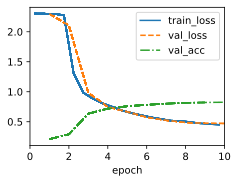

In [5]:
model = AlexNet(lr=0.01)
data = d2l.FashionMNIST(batch_size=128, resize=(224, 224))
trainer = d2l.Trainer(max_epochs=10, num_gpus=1)
trainer.fit(model, data)

### 8.1.4. Discussion

AlexNet's structure bears a striking resemblance to LeNet, with a number of critical improvements, both for accuracy (dropout) and for ease of training (ReLU). What is equally striking is the amount of progress that has been made in terms of deep learning tooling. What was several months of work in 2012 can now be accomplished in a dozen lines of code using any modern framework.

Reviewing the architecture, we see that AlexNet has an Achilles heel when it comes to efficiency: the last two hidden layers require matrices of size $6400 \times 4096$ and $4096 \times 4096$, respectively. This corresponds to 164 MB of memory and 81 MFLOPs of computation, both of which are a nontrivial outlay, especially on smaller devices, such as mobile phones. This is one of the reasons why AlexNet has been surpassed by much more effective architectures that we will cover in the following sections. Nonetheless, it is a key step from shallow to deep networks that are used nowadays. Note that even though the number of parameters exceeds by far the amount of training data in our experiments (the last two layers have more than 40 million parameters, trained on a datasets of 60 thousand images), there is hardly any overfitting: training and validation loss are virtually identical throughout training. This is due to the improved regularization, such as dropout, inherent in modern deep network designs.

Although it seems that there are only a few more lines in AlexNet's implementation than in LeNet's, it took the academic community many years to embrace this conceptual change and take advantage of its excellent experimental results. This was also due to the lack of efficient computational tools. At the time neither DistBelief (Dean et al., 2012) nor Caffe (Jia et al., 2014) existed, and Theano (Bergstra et al., 2010) still lacked many distinguishing features. It was the availability of TensorFlow (Abadi et al., 2016) that dramatically changed the situation.


### 8.1.5. Exercises

1. Following up on the discussion above, analyze the computational properties of AlexNet.
    - Compute the memory footprint for convolutions and fully connected layers, respectively. Which one dominates?
    - Calculate the computational cost for the convolutions and the fully connected layers.
    - How does the memory (read and write bandwidth, latency, size) affect computation? Is there any difference in its effects for training and inference?

1. You are a chip designer and need to trade off computation and memory bandwidth. For example, a faster chip requires more power and possibly a larger chip area. More memory bandwidth requires more pins and control logic, thus also more area. How do you optimize?

1. Why do engineers no longer report performance benchmarks on AlexNet?

1. Try increasing the number of epochs when training AlexNet. Compared with LeNet, how do the results differ? Why?

1. AlexNet may be too complex for the Fashion-MNIST dataset, in particular due to the low resolution of the initial images.
    - Try simplifying the model to make the training faster, while ensuring that the accuracy does not drop significantly.
    - Design a better model that works directly on $28 \times 28$ images.

1. Modify the batch size, and observe the changes in throughput (images/s), accuracy, and GPU memory.

1. Apply dropout and ReLU to LeNet-5. Does it improve? Can you improve things further by preprocessing to take advantage of the invariances inherent in the images?

1. Can you make AlexNet overfit? Which feature do you need to remove or change to break training?

## 8.2. Networks Using Blocks (VGG)

While AlexNet offered empirical evidence that deep CNNs can achieve good results, it did not provide a general template to guide subsequent researchers in designing new networks. In the following sections, we will introduce several heuristic concepts commonly used to design deep networks.

Progress in this field mirrors that of VLSI (very large scale integration) in chip design where engineers moved from placing transistors to logical elements to logic blocks (Mead, 1980). Similarly, the design of neural network architectures has grown progressively more abstract, with researchers moving from thinking in terms of individual neurons to whole layers, and now to blocks, repeating patterns of layers. A decade later, this has now progressed to researchers using entire trained models to repurpose them for different, albeit related, tasks. Such large pretrained models are typically called *foundation models* (Bommasani et al., 2021).

Back to network design. The idea of using blocks first emerged from the Visual Geometry Group (VGG) at Oxford University, in their eponymously-named *VGG* network (Simonyan and Zisserman, 2014). It is easy to implement these repeated structures in code with any modern deep learning framework by using loops and subroutines.

In [1]:
from torch import nn
from d2l import torch as d2l

### 8.2.1. VGG Blocks

The basic building block of CNNs is a sequence of the following: (i) a convolutional layer with padding to maintain the resolution, (ii) a nonlinearity such as a ReLU, (iii) a pooling layer such as max-pooling to reduce the resolution. *One of the problems with this approach is that the spatial resolution decreases quite rapidly*. In particular, this imposes a hard limit of $\log_2 d$ convolutional layers on the network before all dimensions ($d$) are used up. For instance, in the case of ImageNet, it would be impossible to have more than 8 convolutional layers in this way.

The key idea of Simonyan and Zisserman (2014) was to use *multiple* convolutions in between downsampling via max-pooling in the form of a block. They were primarily interested in whether deep or wide networks perform better. For instance, the successive application of two $3 \times 3$ convolutions touches *the same pixels* as a single $5 \times 5$ convolution does. At the same time, the latter uses approximately as many parameters ($25 \cdot c^2$) as three $3 \times 3$ convolutions do ($3 \cdot 9 \cdot c^2$). In a rather detailed analysis they showed that *deep and narrow networks significantly outperform their shallow counterparts*. This set deep learning on a quest for ever deeper networks with over 100 layers for typical applications. Stacking $3 \times 3$ convolutions has become a gold standard in later deep networks (a design decision only to be revisited recently by Liu et al. (2022)). Consequently, fast implementations for small convolutions have become a staple on GPUs (Lavin and Gray, 2016).

Back to VGG: a VGG block consists of a *sequence* of convolutions with $3\times3$ kernels with padding of 1 (keeping height and width) followed by a $2 \times 2$ max-pooling layer with stride of 2 (halving height and width after each block). In the code below, we define a function called `vgg_block` to implement one VGG block.

The function below takes two arguments, corresponding to the number of convolutional layers `num_convs` and the number of output channels `num_channels`.

In [2]:
def vgg_block(num_convs, out_channels):
    layers = []
    for _ in range(num_convs):
        layers.append(nn.LazyConv2d(out_channels, kernel_size=3, padding=1))
        layers.append(nn.ReLU())
    layers.append(nn.MaxPool2d(kernel_size=2,stride=2))
    return nn.Sequential(*layers)

### 8.2.2. VGG Network

Like AlexNet and LeNet, the VGG Network can be partitioned into two parts: the first consisting mostly of convolutional and pooling layers and the second consisting of fully connected layers that are identical to those in AlexNet. The key difference is that the convolutional layers are grouped in nonlinear transformations that leave the dimensonality unchanged, followed by a resolution-reduction step, as depicted in Fig. 8.2.1.

<p align="center">
  <img src="http://d2l.ai/_images/vgg.svg"/>
  <br />
  <em>Fig. 8.2.1</em> From AlexNet to VGG. The key difference is that VGG consists of blocks of layers, whereas AlexNet’s layers are all designed individually.
</p>

The convolutional part of the network connects several VGG blocks from Fig. 8.2.1 (also defined in the `vgg_block` function) in succession. *This grouping of convolutions is a pattern that has remained almost unchanged over the past decade*, although the specific choice of operations has undergone considerable modifications. The variable `arch` consists of a list of tuples (one per block), where each contains two values: the number of convolutional layers and the number of output channels, which are precisely the arguments required to call the `vgg_block` function. As such, VGG defines *a family of networks* rather than just a specific manifestation. To build a specific network we simply iterate over `arch` to compose the blocks.

In [3]:
class VGG(d2l.Classifier):
    def __init__(self, arch, lr=0.1, num_classes=10):
        super().__init__()
        self.save_hyperparameters()
        conv_blks = []
        for (num_convs, out_channels) in arch:
            conv_blks.append(vgg_block(num_convs, out_channels))
        self.net = nn.Sequential(
            *conv_blks, nn.Flatten(),
            nn.LazyLinear(4096), nn.ReLU(), nn.Dropout(0.5),
            nn.LazyLinear(4096), nn.ReLU(), nn.Dropout(0.5),
            nn.LazyLinear(num_classes))
        self.net.apply(d2l.init_cnn)

The original VGG network had five convolutional blocks, among which the first two have one convolutional layer each and the latter three contain two convolutional layers each. The first block has 64 output channels and each subsequent block doubles the number of output channels, until that number reaches 512. Since this network uses eight convolutional layers and three fully connected layers, it is often called VGG-11.

In [4]:
VGG(arch=((1, 64), (1, 128), (2, 256), (2, 512), (2, 512))).layer_summary(
    (1, 1, 224, 224))

/home/lancer/miniforge3/envs/d2l/lib/python3.10/site-packages/torch/nn/modules/lazy.py:181: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


Sequential output shape:	 torch.Size([1, 64, 112, 112])
Sequential output shape:	 torch.Size([1, 128, 56, 56])
Sequential output shape:	 torch.Size([1, 256, 28, 28])
Sequential output shape:	 torch.Size([1, 512, 14, 14])
Sequential output shape:	 torch.Size([1, 512, 7, 7])
Flatten output shape:	 torch.Size([1, 25088])
Linear output shape:	 torch.Size([1, 4096])
ReLU output shape:	 torch.Size([1, 4096])
Dropout output shape:	 torch.Size([1, 4096])
Linear output shape:	 torch.Size([1, 4096])
ReLU output shape:	 torch.Size([1, 4096])
Dropout output shape:	 torch.Size([1, 4096])
Linear output shape:	 torch.Size([1, 10])


As you can see, we halve height and width at each block, finally reaching a height and width of 7 before flattening the representations for processing by the fully connected part of the network. Simonyan and Zisserman (2014) described several other variants of VGG. In fact, it has become the norm to propose *families* of networks with different speed--accuracy trade-off when introducing a new architecture.

### 8.2.3. Training

Since VGG-11 is computationally more demanding than AlexNet we construct a network with a smaller number of channels. This is more than sufficient for training on Fashion-MNIST. The model training process is similar to that of AlexNet in Section 8.1. Again observe the close match between validation and training loss, suggesting only a small amount of overfitting.

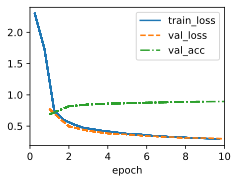

In [5]:
model = VGG(arch=((1, 16), (1, 32), (2, 64), (2, 128), (2, 128)), lr=0.01)
trainer = d2l.Trainer(max_epochs=10, num_gpus=1)
data = d2l.FashionMNIST(batch_size=128, resize=(224, 224))
model.apply_init([next(iter(data.get_dataloader(True)))[0]], d2l.init_cnn)
trainer.fit(model, data)

### 8.2.4. Summary

One might argue that VGG is the first truly modern convolutional neural network. While AlexNet introduced many of the components of what make deep learning effective at scale, it is VGG that arguably introduced key properties such as blocks of multiple convolutions and a preference for deep and narrow networks. It is also the first network that is actually an entire family of similarly parametrized models, *giving the practitioner ample trade-off between complexity and speed*. This is also the place where modern deep learning frameworks shine. It is no longer necessary to generate XML configuration files to specify a network but rather, to assemble said networks through simple Python code.

More recently ParNet (Goyal et al., 2021) demonstrated that it is possible to achieve competitive performance using a much more shallow architecture through a large number of parallel computations. This is an exciting development and there is hope that it will influence architecture designs in the future. For the remainder of the chapter, though, we will follow the path of scientific progress over the past decade.

### 8.2.5. Exercises

1. Compared with AlexNet, VGG is much slower in terms of computation, and it also needs more GPU memory.
    - Compare the number of parameters needed for AlexNet and VGG.
    - Compare the number of floating point operations used in the convolutional layers and in the fully connected layers.
    - How could you reduce the computational cost created by the fully connected layers?

1. When displaying the dimensions associated with the various layers of the network, we only see the information associated with eight blocks (plus some auxiliary transforms), even though the network has 11 layers. Where did the remaining three layers go?

1. Use Table 1 in the VGG paper (Simonyan and Zisserman, 2014) to construct other common models, such as VGG-16 or VGG-19.

1. Upsampling the resolution in Fashion-MNIST eight-fold from $28 \times 28$ to $224 \times 224$ dimensions is very wasteful. Try modifying the network architecture and resolution conversion, e.g., to 56 or to 84 dimensions for its input instead. Can you do so without reducing the accuracy of the network? Consult the VGG paper (Simonyan and Zisserman, 2014) for ideas on adding more nonlinearities prior to downsampling.

## 8.3. Network in Network (NiN)

LeNet, AlexNet, and VGG all share a common design pattern: extract features exploiting *spatial* structure via a sequence of convolutions and pooling layers and post-process the representations via fully connected layers. The improvements upon LeNet by AlexNet and VGG mainly lie in how these later networks widen and deepen these two modules.

This design poses two major challenges. First, the fully connected layers at the end of the architecture consume tremendous numbers of parameters. For instance, even a simple model such as VGG-11 requires a monstrous matrix, occupying almost 400MB of RAM in single precision (FP32). This is a significant impediment to computation, in particular on mobile and embedded devices. After all, even high-end mobile phones sport no more than 8GB of RAM. At the time VGG was invented, this was an order of magnitude less (the iPhone 4S had 512MB). As such, it would have been difficult to justify spending the majority of memory on an image classifier.

Second, it is equally impossible to add fully connected layers earlier in the network to increase the degree of nonlinearity: doing so would destroy the spatial structure and require potentially even more memory.

The *network in network* (*NiN*) blocks (Lin et al., 2013) offer an alternative, capable of solving both problems in one simple strategy. They were proposed based on a very simple insight: (i) use $1 \times 1$ convolutions to add local nonlinearities across the channel activations and (ii) use global average pooling to integrate across all locations in the last representation layer. Note that global average pooling would not be effective, were it not for the added nonlinearities. Let's dive into this in detail.

In [6]:
from torch import nn
from d2l import torch as d2l

### 8.3.1. NiN Blocks

Recall Section 7.4.3. In it we said that the inputs and outputs of convolutional layers consist of four-dimensional tensors with axes corresponding to the example, channel, height, and width. Also recall that the inputs and outputs of fully connected layers are typically two-dimensional tensors corresponding to the example and feature. The idea behind NiN is to apply a fully connected layer at each pixel location (for each height and width). The resulting $1 \times 1$ convolution can be thought of as a fully connected layer acting independently on each pixel location.

Fig. 8.3.1 illustrates the main structural differences between VGG and NiN, and their blocks. Note both the difference in the NiN blocks (the initial convolution is followed by $1 \times 1$ convolutions, whereas VGG retains $3 \times 3$ convolutions) and at the end where we no longer require a giant fully connected layer.

<p align="center">
  <img src="http://d2l.ai/_images/nin.svg"/>
  <br />
  <em>Fig. 8.3.1</em> Comparing the architectures of VGG and NiN, and of their blocks.
</p>

In [7]:
def nin_block(out_channels, kernel_size, strides, padding):
    return nn.Sequential(
        nn.LazyConv2d(out_channels, kernel_size, strides, padding), nn.ReLU(),
        nn.LazyConv2d(out_channels, kernel_size=1), nn.ReLU(),
        nn.LazyConv2d(out_channels, kernel_size=1), nn.ReLU())

---
牧之：用传统的非 $1 \times 1$ 卷积核 + 激活，提取空间特征，随后用 $1 \times 1$ 卷积核 + 激活增加同一空间像素在通道间的非线性。

### 8.3.2. NiN Model

NiN uses the same initial convolution sizes as AlexNet (it was proposed shortly thereafter). The kernel sizes are $11\times 11$, $5\times 5$, and $3\times 3$, respectively, and the numbers of output channels match those of AlexNet. Each NiN block is followed by a max-pooling layer with a stride of 2 and a window shape of $3\times 3$.

The second significant difference between NiN and both AlexNet and VGG is that NiN avoids fully connected layers altogether. Instead, NiN uses a NiN block with a number of output channels equal to the number of label classes, followed by a *global* average pooling layer, yielding a vector of logits. This design significantly reduces the number of required model parameters, albeit at the expense of a potential increase in training time.

In [8]:
class NiN(d2l.Classifier):
    def __init__(self, lr=0.1, num_classes=10):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(
            nin_block(96, kernel_size=11, strides=4, padding=0),
            nn.MaxPool2d(3, stride=2),
            nin_block(256, kernel_size=5, strides=1, padding=2),
            nn.MaxPool2d(3, stride=2),
            nin_block(384, kernel_size=3, strides=1, padding=1),
            nn.MaxPool2d(3, stride=2),
            nn.Dropout(0.5),
            nin_block(num_classes, kernel_size=3, strides=1, padding=1),
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten())
        self.net.apply(d2l.init_cnn)

We create a data example to see the output shape of each block.

In [9]:
NiN().layer_summary((1, 1, 224, 224))

Sequential output shape:	 torch.Size([1, 96, 54, 54])
MaxPool2d output shape:	 torch.Size([1, 96, 26, 26])
Sequential output shape:	 torch.Size([1, 256, 26, 26])
MaxPool2d output shape:	 torch.Size([1, 256, 12, 12])
Sequential output shape:	 torch.Size([1, 384, 12, 12])
MaxPool2d output shape:	 torch.Size([1, 384, 5, 5])
Dropout output shape:	 torch.Size([1, 384, 5, 5])
Sequential output shape:	 torch.Size([1, 10, 5, 5])
AdaptiveAvgPool2d output shape:	 torch.Size([1, 10, 1, 1])
Flatten output shape:	 torch.Size([1, 10])


### 8.3.3. Training

As before we use Fashion-MNIST to train the model using the same optimizer that we used for AlexNet and VGG.

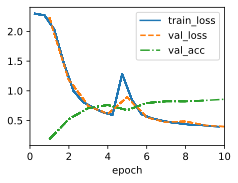

In [10]:
model = NiN(lr=0.05)
trainer = d2l.Trainer(max_epochs=10, num_gpus=1)
data = d2l.FashionMNIST(batch_size=128, resize=(224, 224))
model.apply_init([next(iter(data.get_dataloader(True)))[0]], d2l.init_cnn)
trainer.fit(model, data)

### 8.3.4. Summary

NiN has dramatically fewer parameters than AlexNet and VGG. This stems primarily from the fact that it needs no giant fully connected layers. Instead, it uses global average pooling to aggregate across all image locations after the last stage of the network body. This obviates the need for expensive (learned) reduction operations and replaces them by a simple average. **What surprised researchers at the time was the fact that this averaging operation did not harm accuracy**. Note that averaging across a low-resolution representation (with many channels) also adds to the amount of translation invariance that the network can handle.

Choosing fewer convolutions with wide kernels and replacing them by $1 \times 1$ convolutions aids the quest for fewer parameters further. It can cater for a significant amount of nonlinearity across channels within any given location. Both $1 \times 1$ convolutions and global average pooling significantly influenced subsequent CNN designs.

### 8.3.5. Exercises

1. Why are there two $1\times 1$ convolutional layers per NiN block? Increase their number to three. Reduce their number to one. What changes?

1. What changes if you replace the $1 \times 1$ convolutions by $3 \times 3$ convolutions?

1. What happens if you replace the global average pooling by a fully connected layer (speed, accuracy, number of parameters)?

1. Calculate the resource usage for NiN.
    - What is the number of parameters?
    - What is the amount of computation?
    - What is the amount of memory needed during training?
    - What is the amount of memory needed during prediction?

1. What are possible problems with reducing the $384 \times 5 \times 5$ representation to a $10 \times 5 \times 5$ representation in one step?

1. Use the structural design decisions in VGG that led to VGG-11, VGG-16, and VGG-19 to design a family of NiN-like networks.

## 8.4. Multi-Branch Networks (GoogLeNet)

In 2014, *GoogLeNet* won the ImageNet Challenge (Szegedy et al., 2015), using a structure that combined the strengths of NiN (Lin et al., 2013), repeated blocks (Simonyan and Zisserman, 2014), and a cocktail of convolution kernels. *It was arguably also the first network that exhibited a clear distinction among the stem (data ingest), body (data processing), and head (prediction) in a CNN*. This design pattern has persisted ever since in the design of deep networks: the ***stem*** is given by the first two or three convolutions that operate on the image. They extract low-level features from the underlying images. This is followed by a ***body*** of convolutional blocks. Finally, the ***head*** maps the features obtained so far to the required classification, segmentation, detection, or tracking problem at hand.

*The key contribution in GoogLeNet was the design of the network body*. It solved the problem of selecting convolution kernels in an ingenious way. While other works tried to identify which convolution, ranging from $1 \times 1$ to $11 \times 11$ would be best, it simply *concatenated* multi-branch convolutions. In what follows we introduce a slightly simplified version of GoogLeNet: the original design included a number of tricks for stabilizing training through intermediate loss functions, applied to multiple layers of the network. They are no longer necessary due to the availability of improved training algorithms.

In [1]:
import torch
from torch import nn
from torch.nn import functional as F
from d2l import torch as d2l

### 8.4.1. Inception Blocks

The basic convolutional block in GoogLeNet is called an *Inception block*, stemming from the meme "we need to go deeper" from the movie *Inception*.

<p align="center">
  <img src="http://d2l.ai/_images/inception.svg"/>
  <br />
  <em>Fig. 8.4.1</em> Structure of the Inception block.
</p>

As depicted in Fig. 8.4.1, the inception block consists of four parallel branches. The first three branches use convolutional layers with window sizes of $1\times 1$, $3\times 3$, and $5\times 5$ to extract information from different spatial sizes. The middle two branches also add a $1\times 1$ convolution of the input to *reduce the number of channels*, reducing the model's complexity. The fourth branch uses a $3\times 3$ max-pooling layer, followed by a $1\times 1$ convolutional layer to change the number of channels. The four branches all use appropriate padding to give the input and output the same height and width. Finally, the outputs along each branch are concatenated along the channel dimension and comprise the block's output. The commonly-tuned hyperparameters of the Inception block are the number of output channels per layer, i.e., how to allocate capacity among convolutions of different size.

In [2]:
class Inception(nn.Module):
    # c1--c4 are the number of output channels for each branch
    def __init__(self, c1, c2, c3, c4, **kwargs):
        super(Inception, self).__init__(**kwargs)
        # Branch 1
        self.b1_1 = nn.LazyConv2d(c1, kernel_size=1)
        # Branch 2
        self.b2_1 = nn.LazyConv2d(c2[0], kernel_size=1)
        self.b2_2 = nn.LazyConv2d(c2[1], kernel_size=3, padding=1)
        # Branch 3
        self.b3_1 = nn.LazyConv2d(c3[0], kernel_size=1)
        self.b3_2 = nn.LazyConv2d(c3[1], kernel_size=5, padding=2)
        # Branch 4
        self.b4_1 = nn.MaxPool2d(kernel_size=3, stride=1, padding=1)
        self.b4_2 = nn.LazyConv2d(c4, kernel_size=1)

    def forward(self, x):
        b1 = F.relu(self.b1_1(x))
        b2 = F.relu(self.b2_2(F.relu(self.b2_1(x))))
        b3 = F.relu(self.b3_2(F.relu(self.b3_1(x))))
        b4 = F.relu(self.b4_2(self.b4_1(x)))
        return torch.cat((b1, b2, b3, b4), dim=1)

To gain some intuition for why this network works so well, consider the combination of the filters. ***They explore the image in a variety of filter sizes***. This means that details at different extents can be recognized efficiently by filters of different sizes. At the same time, we can allocate different amounts of parameters for different filters.

### 8.4.2. GoogLeNet Model

As shown in Fig. 8.4.2, GoogLeNet uses a stack of a total of 9 inception blocks, arranged into three groups with max-pooling in between, and global average pooling in its head to generate its estimates. Max-pooling between inception blocks reduces the dimensionality. At its stem, the first module is similar to AlexNet and LeNet.

<p align="center">
  <img src="https://d2l.ai/_images/inception-full-90.svg"/>
  <br />
  <em>Fig. 8.4.2</em> The GoogLeNet architecture.
</p>

We can now implement GoogLeNet piece by piece. Let's begin with the stem. The first module uses a 64-channel $7\times 7$ convolutional layer.

In [3]:
class GoogleNet(d2l.Classifier):
    def b1(self):
        return nn.Sequential(
            nn.LazyConv2d(64, kernel_size=7, stride=2, padding=3),
            nn.ReLU(), nn.MaxPool2d(kernel_size=3, stride=2, padding=1))

The second module uses two convolutional layers: first, a 64-channel $1\times 1$ convolutional layer, followed by a $3\times 3$ convolutional layer that triples the number of channels. This corresponds to the second branch in the Inception block and concludes the design of the body. At this point we have 192 channels.

In [4]:
@d2l.add_to_class(GoogleNet)
def b2(self):
    return nn.Sequential(
        nn.LazyConv2d(64, kernel_size=1), nn.ReLU(),
        nn.LazyConv2d(192, kernel_size=3, padding=1), nn.ReLU(),
        nn.MaxPool2d(kernel_size=3, stride=2, padding=1))

The third module connects two complete Inception blocks in series. The number of output channels of the first Inception block is $64+128+32+32=256$. This amounts to a ratio of the number of output channels among the four branches of $2:4:1:1$. To achieve this, we first reduce the input dimensions by $\frac{1}{2}$ and by $\frac{1}{12}$ in the second and third branch respectively to arrive at $96 = 192/2$ and $16 = 192/12$ channels respectively.

The number of output channels of the second Inception block is increased to $128+192+96+64=480$, yielding a ratio of $128:192:96:64 = 4:6:3:2$. As before, we need to reduce the number of intermediate dimensions in the second and third channel. A scale of $\frac{1}{2}$ and $\frac{1}{8}$ respectively suffices, yielding $128$ and $32$ channels respectively. This is captured by the arguments of the following `Inception` block constructors.

In [5]:
@d2l.add_to_class(GoogleNet)
def b3(self):
    return nn.Sequential(Inception(64, (96, 128), (16, 32), 32),
                         Inception(128, (128, 192), (32, 96), 64),
                         nn.MaxPool2d(kernel_size=3, stride=2, padding=1))

The fourth module is more complicated. It connects five Inception blocks in series, and they have $192+208+48+64=512$, $160+224+64+64=512$, $128+256+64+64=512$, $112+288+64+64=528$, and $256+320+128+128=832$ output channels, respectively. The number of channels assigned to these branches is similar to that in the third module: the second branch with the $3\times 3$ convolutional layer outputs the largest number of channels, followed by the first branch with only the $1\times 1$ convolutional layer, the third branch with the $5\times 5$ convolutional layer, and the fourth branch with the $3\times 3$ max-pooling layer. The second and third branches will first reduce the number of channels according to the ratio. These ratios are slightly different in different Inception blocks.

In [6]:
@d2l.add_to_class(GoogleNet)
def b4(self):
    return nn.Sequential(Inception(192, (96, 208), (16, 48), 64),
                         Inception(160, (112, 224), (24, 64), 64),
                         Inception(128, (128, 256), (24, 64), 64),
                         Inception(112, (144, 288), (32, 64), 64),
                         Inception(256, (160, 320), (32, 128), 128),
                         nn.MaxPool2d(kernel_size=3, stride=2, padding=1))

The fifth module has two Inception blocks with $256+320+128+128=832$ and $384+384+128+128=1024$ output channels. The number of channels assigned to each branch is the same as that in the third and fourth modules, but differs in specific values. It should be noted that the fifth block is followed by the output layer. This block uses the global average pooling layer to change the height and width of each channel to 1, just as in NiN. Finally, we turn the output into a two-dimensional array followed by a fully connected layer whose number of outputs is the number of label classes.

In [7]:
@d2l.add_to_class(GoogleNet)
def b5(self):
    return nn.Sequential(Inception(256, (160, 320), (32, 128), 128),
                         Inception(384, (192, 384), (48, 128), 128),
                         nn.AdaptiveAvgPool2d((1,1)), nn.Flatten())

Now that we defined all blocks `b1` through `b5`, it is just a matter of assembling them all into a full network.

In [8]:
@d2l.add_to_class(GoogleNet)
def __init__(self, lr=0.1, num_classes=10):
    super(GoogleNet, self).__init__()
    self.save_hyperparameters()
    self.net = nn.Sequential(self.b1(), self.b2(), self.b3(), self.b4(),
                             self.b5(), nn.LazyLinear(num_classes))
    self.net.apply(d2l.init_cnn)

The GoogLeNet model is computationally complex. Note the large number of relatively arbitrary hyperparameters in terms of the number of channels chosen, the number of blocks prior to dimensionality reduction, the relative partitioning of capacity across channels, etc. Much of it is due to the fact that at the time when GoogLeNet was introduced, automatic tools for network definition or design exploration were not yet available. For instance, by now we take it for granted that a competent deep learning framework is capable of inferring dimensionalities of input tensors automatically. At the time, many such configurations had to be specified explicitly by the experimenter, thus often slowing down active experimentation. Moreover, the tools needed for automatic exploration were still in flux and initial experiments largely amounted to costly brute-force exploration, genetic algorithms, and similar strategies.

For now the only modification we will carry out is to reduce the input height and width from 224 to 96 to have a reasonable training time on Fashion-MNIST. This simplifies the computation. Let's have a look at the changes in the shape of the output between the various modules.

In [9]:
model = GoogleNet().layer_summary((1, 1, 96, 96))

Sequential output shape:	 torch.Size([1, 64, 24, 24])
Sequential output shape:	 torch.Size([1, 192, 12, 12])
Sequential output shape:	 torch.Size([1, 480, 6, 6])
Sequential output shape:	 torch.Size([1, 832, 3, 3])
Sequential output shape:	 torch.Size([1, 1024])
Linear output shape:	 torch.Size([1, 10])


/home/lancer/miniforge3/envs/d2l/lib/python3.10/site-packages/torch/nn/modules/lazy.py:181: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


### 8.4.3. Training

As before, we train our model using the Fashion-MNIST dataset. We transform it to $96 \times 96$ pixel resolution before invoking the training procedure.

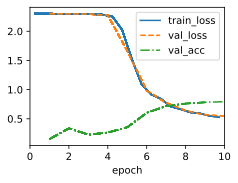

In [10]:
model = GoogleNet(lr=0.01)
trainer = d2l.Trainer(max_epochs=10, num_gpus=1)
data = d2l.FashionMNIST(batch_size=128, resize=(96, 96))
model.apply_init([next(iter(data.get_dataloader(True)))[0]], d2l.init_cnn)
trainer.fit(model, data)

### 8.4.4. Discussion

A key feature of GoogLeNet is that it is actually *cheaper* to compute than its predecessors while simultaneously providing improved accuracy. This marks the beginning of a much more deliberate network design that trades off the cost of evaluating a network with a reduction in errors. It also marks the beginning of experimentation at a block level with network design hyperparameters, even though it was entirely manual at the time. We will revisit this topic in Section 8.8 when discussing strategies for network structure exploration.

Over the following sections we will encounter a number of design choices (e.g., batch normalization, residual connections, and channel grouping) that allow us to improve networks significantly. For now, you can be proud to have implemented what is arguably the first truly modern CNN.

### 8.4.5. Exercises

1. GoogLeNet was so successful that it went through a number of iterations, progressively improving speed and accuracy. Try to implement and run some of them. They include the following:
  - Add a batch normalization layer (Ioffe and Szegedy, 2015), as described later in Section 8.5.
  - Make adjustments to the Inception block (width, choice and order of convolutions), as described in Szegedy et al. (2016).
  - Use label smoothing for model regularization, as described in Szegedy et al. (2016).
  - Make further adjustments to the Inception block by adding residual connection (Szegedy et al., 2017), as described later in Section 8.6.

1. What is the minimum image size needed for GoogLeNet to work?

1. Can you design a variant of GoogLeNet that works on Fashion-MNIST's native resolution of $28 \times 28$ pixels? How would you need to change the stem, the body, and the head of the network, if anything at all?

1. Compare the model parameter sizes of AlexNet, VGG, NiN, and GoogLeNet. How do the latter two network architectures significantly reduce the model parameter size?

1. Compare the amount of computation needed in GoogLeNet and AlexNet. How does this affect the design of an accelerator chip, e.g., in terms of memory size, memory bandwidth, cache size, the amount of computation, and the benefit of specialized operations?

## 8.5. Batch Normalization

Training deep neural networks is difficult. Getting them to converge in a reasonable amount of time can be tricky. In this section, we describe *batch normalization*, a popular and effective technique that consistently accelerates the convergence of deep networks (Ioffe and Szegedy, 2015). Together with residual blocks—covered later in Section 8.6—batch normalization has made it possible for practitioners to routinely train networks with over 100 layers. A secondary (serendipitous) benefit of batch normalization lies in its inherent regularization.

In [ ]:
import torch
from torch import nn
from d2l import torch as d2l

### 8.5.1. Training Deep Networks

When working with data, we often preprocess before training. Choices regarding data preprocessing often make an enormous difference in the final results. Recall our application of MLPs to predicting house prices (Section 5.7). Our first step when working with real data was to standardize our input features to have zero mean $\boldsymbol{\mu} = 0$ and unit variance $\boldsymbol{\Sigma} = \boldsymbol{1}$ across multiple observations (Friedman, 1987), frequently rescaling the latter so  that the diagonal is unity, i.e., $\Sigma_{ii} = 1$. Yet another strategy is to rescale vectors to unit length, possibly zero mean *per observation*. This can work well, e.g., for spatial sensor data. These preprocessing techniques and many others, are beneficial for keeping the estimation problem well controlled. For a review of feature selection and extraction see the article of Guyon et al. (2008), for example. Standardizing vectors also has the nice side-effect of constraining the function complexity of functions that act upon it. For instance, the celebrated radius-margin bound (Vapnik, 1995) in support vector machines and the Perceptron Convergence Theorem (Novikoff, 1962) rely on inputs of bounded norm.

Intuitively, this standardization plays nicely with our optimizers since it puts the parameters *a priori* on a similar scale. As such, it is only natural to ask whether a corresponding normalization step *inside* a deep network might not be beneficial. While this is not quite the reasoning that led to the invention of batch normalization (Ioffe and Szegedy, 2015), it is a useful way of understanding it and its cousin, layer normalization (Ba et al., 2016), within a unified framework.

Second, for a typical MLP or CNN, as we train, the variables in intermediate layers (e.g., affine transformation outputs in MLP) may take values with widely varying magnitudes: whether along the layers from input to output, across units in the same layer, and over time due to our updates to the model parameters. The inventors of batch normalization postulated informally that this drift in the distribution of such variables could hamper the convergence of the network. Intuitively, we might conjecture that if one layer has variable activations that are 100 times that of another layer, this might necessitate compensatory adjustments in the learning rates. Adaptive solvers such as AdaGrad (Duchi et al., 2011), Adam (Kingma and Ba, 2014), Yogi (Zaheer et al., 2018), or Distributed Shampoo (Anil et al., 2020) aim to address this from the viewpoint of optimization, e.g., by adding aspects of second-order methods. The alternative is to prevent the problem from occurring, simply by adaptive normalization.

Third, deeper networks are complex and tend to be more liable to overfitting. This means that regularization becomes more critical. A common technique for regularization is noise injection. This has been known for a long time, e.g., with regard to noise injection for the inputs (Bishop, 1995). It also forms the basis of dropout in Section 5.6. As it turns out, quite serendipitously, batch normalization conveys all three benefits: preprocessing, numerical stability, and regularization.

Batch normalization is applied to individual layers, or optionally, to all of them: In each training iteration, we first normalize the inputs (of batch normalization) by subtracting their mean and dividing by their standard deviation, where both are estimated based on the statistics of the current minibatch. *Next, we apply a scale coefficient and an offset to recover the lost degrees of freedom*. It is precisely due to this *normalization* based on *batch* statistics that *batch normalization* derives its name.

Note that if we tried to apply batch normalization with minibatches of size 1, we would not be able to learn anything. That is because after subtracting the means, each hidden unit would take value 0. As you might guess, since we are devoting a whole section to batch normalization, with large enough minibatches the approach proves effective and stable. One takeaway here is that when applying batch normalization, the choice of batch size is even more significant than without batch normalization, or at least, suitable calibration is needed as we might adjust batch size.

Denote by $\mathcal{B}$ a minibatch and let $\mathbf{x} \in \mathcal{B}$ be an input to batch normalization ($\textrm{BN}$). In this case the batch normalization is defined as follows:

$$\textrm{BN}(\mathbf{x}) = \boldsymbol{\gamma} \odot \frac{\mathbf{x} - \hat{\boldsymbol{\mu}}_\mathcal{B}}{\hat{\boldsymbol{\sigma}}_\mathcal{B}} + \boldsymbol{\beta}. \tag{8.5.1} $$

In (8.5.1), $\hat{\boldsymbol{\mu}}_\mathcal{B}$ is the  sample mean and $\hat{\boldsymbol{\sigma}}_\mathcal{B}$ is the sample standard deviation of the minibatch $\mathcal{B}$. After applying standardization, the resulting minibatch has zero mean and unit variance. The choice of unit variance (rather than some other magic number) is arbitrary. We recover this degree of freedom by including an elementwise *scale parameter* $\boldsymbol{\gamma}$ and *shift parameter* $\boldsymbol{\beta}$ that have the same shape as $\mathbf{x}$. Both are parameters that need to be learned as part of model training.

The variable magnitudes for intermediate layers cannot diverge during training since batch normalization actively centers and rescales them back to a given mean and size (via $\hat{\boldsymbol{\mu}}_\mathcal{B}$ and ${\hat{\boldsymbol{\sigma}}_\mathcal{B}}$). Practical experience confirms that, as alluded to when discussing feature rescaling, batch normalization seems to allow for more aggressive learning rates. We calculate $\hat{\boldsymbol{\mu}}_\mathcal{B}$ and ${\hat{\boldsymbol{\sigma}}_\mathcal{B}}$ in (8.5.1) as follows:

$$\hat{\boldsymbol{\mu}}_\mathcal{B} = \frac{1}{|\mathcal{B}|} \sum_{\mathbf{x} \in \mathcal{B}} \mathbf{x} \textrm{ and } \hat{\boldsymbol{\sigma}}_\mathcal{B}^2 = \frac{1}{|\mathcal{B}|} \sum_{\mathbf{x} \in \mathcal{B}} (\mathbf{x} - \hat{\boldsymbol{\mu}}_{\mathcal{B}})^2 + \epsilon. \tag{8.5.2} $$

Note that we add a small constant $\epsilon > 0$ to the variance estimate to ensure that we never attempt division by zero, even in cases where the empirical variance estimate might be very small or vanish. The estimates $\hat{\boldsymbol{\mu}}_\mathcal{B}$ and ${\hat{\boldsymbol{\sigma}}_\mathcal{B}}$ counteract the scaling issue by using noisy estimates of mean and variance. You might think that this noisiness should be a problem. On the contrary, it is actually beneficial.

This turns out to be a recurring theme in deep learning. *For reasons that are not yet well-characterized theoretically, various sources of noise in optimization often lead to faster training and less overfitting: this variation appears to act as a form of regularization*. Teye et al. (2018) and Luo et al. (2018) related the properties of batch normalization to Bayesian priors and penalties, respectively. In particular, this sheds some light on the puzzle of why *batch normalization works best for moderate minibatch sizes in the 50--100 range*. This particular size of minibatch seems to inject just the "right amount" of noise per layer, both in terms of scale via $\hat{\boldsymbol{\sigma}}$, and in terms of offset via $\hat{\boldsymbol{\mu}}$: a larger minibatch regularizes less due to the more stable estimates, whereas tiny minibatches destroy useful signal due to high variance. Exploring this direction further, considering alternative types of preprocessing and filtering may yet lead to other effective types of regularization.

Fixing a trained model, you might think that we would prefer using the entire dataset to estimate the mean and variance. Once training is complete, why would we want the same image to be classified differently, depending on the batch in which it happens to reside? During training, such exact calculation is infeasible because the intermediate variables for all data examples change every time we update our model. However, once the model is trained, we can calculate the means and variances of each layer's variables based on the entire dataset. Indeed this is standard practice for models employing batch normalization; thus batch normalization layers function differently in *training mode* (normalizing by minibatch statistics) than in *prediction mode* (normalizing by dataset statistics). In this form they closely resemble the behavior of dropout regularization of Section 5.6, where noise is only injected during training.

---

这段文字系统地介绍了**批归一化**（Batch Normalization, BN）的动机、原理、实现细节及其在深度学习中的多重作用。以下是对全文的逐层解读与总结：

**一、背景：数据预处理的重要性**

- 在训练模型前，对输入数据进行**标准化**（standardization）是常见且关键的步骤：
  - 使特征具有**零均值**（$\mu = 0$）和**单位方差**（$\Sigma_{ii} = 1$）。
  - 或将每个样本向量**归一化为单位长度**（常用于传感器等空间数据）。
- 这类预处理有助于：
  - **稳定优化过程**（参数初始尺度相近，利于优化器工作）；
  - **控制函数复杂度**（如SVM中的半径-间隔界、感知机收敛定理都依赖有界输入范数）；
  - **提升泛化能力**。

> ✅ 核心思想：**良好的输入分布 → 更易训练、更稳定、更泛化。**

**二、从输入标准化到“内部标准化”的自然延伸**

既然输入标准化有效，那么是否可以在**网络内部每一层**也做类似操作？  
这引出了**批归一化（BatchNorm）** 和 **层归一化（LayerNorm）** 的动机。

**为什么需要内部归一化？**

1. **中间层激活值分布不稳定（Internal Covariate Shift）**  
   - 随着训练进行，各层输入的分布会不断变化（因参数更新）；
   - 不同层、不同神经元之间的激活值量级可能相差巨大（如一层是另一层的100倍）；
   - 这迫使优化器需用极小的学习率，或依赖自适应优化器（如Adam）来补偿。

2. **深层网络更容易过拟合**  
   - 需要更强的正则化手段；
   - 而**噪声注入**（如Dropout、输入加噪）已被证明有效。

> 🎯 批归一化**意外地同时解决了三个问题**：  
> （1）内部数据预处理；（2）数值稳定性；（3）正则化。

**三、批归一化的数学定义**

对一个 minibatch $\mathcal{B}$ 中的每个输入 $\mathbf{x}$，BN 定义为：

$$
\textrm{BN}(\mathbf{x}) = \boldsymbol{\gamma} \odot \frac{\mathbf{x} - \hat{\boldsymbol{\mu}}_\mathcal{B}}{\hat{\boldsymbol{\sigma}}_\mathcal{B}} + \boldsymbol{\beta}
$$

其中：
- $\hat{\boldsymbol{\mu}}_\mathcal{B} = \dfrac{1}{|\mathcal{B}|} \sum_{\mathbf{x} \in \mathcal{B}} \mathbf{x}$：batch 均值；
- $\hat{\boldsymbol{\sigma}}_\mathcal{B}^2 = \dfrac{1}{|\mathcal{B}|} \sum_{\mathbf{x} \in \mathcal{B}} (\mathbf{x} - \hat{\boldsymbol{\mu}}_{\mathcal{B}})^2 + \epsilon$：batch 方差（加 $\epsilon > 0$ 防除零）；
- $\boldsymbol{\gamma}, \boldsymbol{\beta}$：可学习的**缩放**和**偏移**参数（恢复表达能力）。

> 🔑 关键点：BN **不是固定变换**，而是带可学习参数的**自适应归一化层**。

**四、批归一化的三大优势详解**

1、**防止激活值发散**
- 每次前向传播时，BN 强制将激活值拉回到零均值、单位方差附近；
- 避免梯度爆炸/消失，使训练更稳定。

2、**允许使用更大的学习率**
- 因为输入分布被“约束”，优化路径更平滑；
- 实践中常可提速训练 5–10 倍。

3、**隐式正则化（Implicit Regularization）**
- 使用 **minibatch 统计量**（而非全集）引入了**噪声**：
  - $\hat{\mu}_\mathcal{B}$ 和 $\hat{\sigma}_\mathcal{B}$ 是带噪声的估计；
  - 这种噪声起到了类似 Dropout 的正则化效果。
- **最优 batch size ≈ 50–100**：
  - 太小（如1）：噪声过大，信号被淹没（所有激活变0）；
  - 太大：噪声太小，正则化效果减弱；
  - 中等大小：**恰到好处的噪声 → 最佳泛化**。

> 📌 理论解释（Teye & Luo）：BN 可视为施加了某种**贝叶斯先验**或**惩罚项**。

**五、训练 vs 推理时的行为差异**

- **训练时**：使用当前 minibatch 的 $\hat{\mu}, \hat{\sigma}$ → 引入噪声，正则化；
- **推理时**：使用**整个训练集**统计的**固定均值与方差**（通常通过移动平均估计）→ 确定性输出。

> ⚠️ 若推理时仍用 batch 统计，同一输入在不同 batch 中输出不同 → 不可接受！  
> 因此 BN 层必须区分 `training mode` 和 `evaluation mode`（类似 Dropout）。

**六、总结：批归一化为何成功？**

| 作用 | 机制 |
|------|------|
| **稳定训练** | 控制中间层激活分布，缓解 Internal Covariate Shift |
| **加速收敛** | 允许更大 LR，减少对初始化的敏感性 |
| **正则化** | minibatch 噪声 → 隐式防止过拟合 |
| **提升泛化** | 尤其在中等 batch size 下效果最佳 |

**补充思考**

- BN 并非万能：在 batch size 极小时失效（如目标检测中的 RoI）→ 促使 LayerNorm、GroupNorm 等替代方案出现。
- 最新研究认为 “Internal Covariate Shift” 并非 BN 主要作用机制，**平滑 loss landscape** 和 **正则化效应**可能更重要。

✅ **一句话总结**：  
**批归一化通过在训练中对每层激活值进行 minibatch 级别的动态标准化，并辅以可学习的仿射变换，在提升训练稳定性的同时，意外获得了强大的正则化能力，成为现代深度网络的标配组件之一。**

---

牧之：为什么要有两个参数？而不是直接使用标准化公式呢？

### 8.5.2. Batch Normalization Layers

Batch normalization implementations for fully connected layers and convolutional layers are slightly different. One key difference between batch normalization and other layers is that because the former operates on a full minibatch at a time, we cannot just ignore the batch dimension as we did before when introducing other layers.

#### 8.5.2.1. Fully Connected Layers

When applying batch normalization to fully connected layers, Ioffe and Szegedy (2015), in their original paper inserted batch normalization after the affine transformation and *before* the nonlinear activation function. Later applications experimented with inserting batch normalization right *after* activation functions. Denoting the input to the fully connected layer by $\mathbf{x}$, the affine transformation by $\mathbf{W}\mathbf{x} + \mathbf{b}$ (with the weight parameter $\mathbf{W}$ and the bias parameter $\mathbf{b}$), and the activation function by $\phi$, we can express the computation of a batch-normalization-enabled, fully connected layer output $\mathbf{h}$ as follows:

$$\mathbf{h} = \phi(\textrm{BN}(\mathbf{W}\mathbf{x} + \mathbf{b}) ). \tag{8.5.3} $$

Recall that mean and variance are computed on the *same* minibatch on which the transformation is applied.

#### 8.5.2.2. Convolutional Layers

Similarly, with convolutional layers, we can apply batch normalization after the convolution but before the nonlinear activation function. The key difference from batch normalization in fully connected layers is that we apply the operation on a per-channel basis *across all locations*. This is compatible with our assumption of translation invariance that led to convolutions: we assumed that the specific location of a pattern within an image was not critical for the purpose of understanding.

Assume that our minibatches contain $m$ examples and that for each channel, the output of the convolution has height $p$ and width $q$. For convolutional layers, we carry out each batch normalization over the $m \cdot p \cdot q$ elements per output channel simultaneously. Thus, we collect the values over all spatial locations when computing the mean and variance and consequently apply the same mean and variance within a given channel to normalize the value at each spatial location. Each channel has its own scale and shift parameters, both of which are scalars.

#### 8.5.2.3. Layer Normalization

Note that in the context of convolutions the batch normalization is well defined even for minibatches of size 1: after all, we have all the locations across an image to average. Consequently, mean and variance are well defined, even if it is just within a single observation. This consideration led Ba et al. (2016) to introduce the notion of *layer normalization*. It works just like a batch norm, only that it is applied to one observation at a time. Consequently both the offset and the scaling factor are scalars. For an $n$-dimensional vector $\mathbf{x}$, layer norms are given by

$$\mathbf{x} \rightarrow \textrm{LN}(\mathbf{x}) =  \frac{\mathbf{x} - \hat{\mu}}{\hat\sigma}, \tag{8.5.4} $$

where scaling and offset are applied coefficient-wise and given by

$$\hat{\mu} \stackrel{\textrm{def}}{=} \frac{1}{n} \sum_{i=1}^n x_i \textrm{ and } \hat{\sigma}^2 \stackrel{\textrm{def}}{=} \frac{1}{n} \sum_{i=1}^n (x_i - \hat{\mu})^2 + \epsilon. \tag{8.5.5} $$

As before we add a small offset $\epsilon > 0$ to prevent division by zero. One of the major benefits of using layer normalization is that it prevents divergence. After all, ignoring $\epsilon$, the output of the layer normalization is scale independent. That is, we have $\textrm{LN}(\mathbf{x}) \approx \textrm{LN}(\alpha \mathbf{x})$ for any choice of $\alpha \neq 0$. This becomes an equality for $|\alpha| \to \infty$ (the approximate equality is due to the offset $\epsilon$ for the variance).

Another advantage of the layer normalization is that it does not depend on the minibatch size. It is also independent of whether we are in training or test regime. In other words, *it is simply a deterministic transformation that standardizes the activations to a given scale*. This can be very beneficial in preventing divergence in optimization. We skip further details and recommend that interested readers consult the original paper.

#### 8.5.2.4. Batch Normalization During Prediction

Batch normalization implementations for fully connected layers and convolutional layers are slightly different. One key difference between batch normalization and other layers is that because the former operates on a full minibatch at a time, we cannot just ignore the batch dimension as we did before when introducing other layers.

Typically, after training, we use the entire dataset to compute stable estimates of the variable statistics and then fix them at prediction time. Hence, batch normalization behaves differently during training than at test time. Recall that dropout also exhibits this characteristic.

### 8.5.3. Implementation from Scratch

To see how batch normalization works in practice, we implement one from scratch below.

In [11]:
def batch_norm(X, gamma, beta, moving_mean, moving_var, eps, momentum):
    # Use is_grad_enabled to determine whether we are in training mode
    if not torch.is_grad_enabled():
        # In prediction mode, use mean and variance obtained by moving average
        X_hat = (X - moving_mean) / torch.sqrt(moving_var + eps)
    else:
        assert len(X.shape) in (2, 4)
        if len(X.shape) == 2:
            # When using a fully connected layer, calculate the mean and
            # variance on the feature dimension
            mean = X.mean(dim=0)
            var = ((X - mean) ** 2).mean(dim=0)
        else:
            # When using a two-dimensional convolutional layer, calculate the
            # mean and variance on the channel dimension (axis=1). Here we
            # need to maintain the shape of X, so that the broadcasting
            # operation can be carried out later
            mean = X.mean(dim=(0, 2, 3), keepdim=True)
            var = ((X - mean) ** 2).mean(dim=(0, 2, 3), keepdim=True)
        # In training mode, the current mean and variance are used
        X_hat = (X - mean) / torch.sqrt(var + eps)
        # Update the mean and variance using moving average
        moving_mean = (1.0 - momentum) * moving_mean + momentum * mean
        moving_var = (1.0 - momentum) * moving_var + momentum * var
    Y = gamma * X_hat + beta  # Scale and shift
    return Y, moving_mean.data, moving_var.data

We can now create a proper `BatchNorm` layer. Our layer will maintain proper parameters for scale `gamma` and shift `beta`, both of which will be updated in the course of training. Additionally, our layer will maintain moving averages of the means and variances for subsequent use during model prediction.

Putting aside the algorithmic details, note the design pattern underlying our implementation of the layer. Typically, we define the mathematics in a separate function, say `batch_norm`. We then integrate this functionality into a custom layer, whose code mostly addresses bookkeeping matters, such as moving data to the right device context, allocating and initializing any required variables, keeping track of moving averages (here for mean and variance), and so on. This pattern enables a clean separation of mathematics from boilerplate code. Also note that for the sake of convenience we did not worry about automatically inferring the input shape here; thus we need to specify the number of features throughout. By now all modern deep learning frameworks offer automatic detection of size and shape in the high-level batch normalization APIs (in practice we will use this instead).

In [12]:
class BatchNorm(nn.Module):
    # num_features: the number of outputs for a fully connected layer or the
    # number of output channels for a convolutional layer. num_dims: 2 for a
    # fully connected layer and 4 for a convolutional layer
    def __init__(self, num_features, num_dims):
        super().__init__()
        if num_dims == 2:
            shape = (1, num_features)
        else:
            shape = (1, num_features, 1, 1)
        # The scale parameter and the shift parameter (model parameters) are
        # initialized to 1 and 0, respectively
        self.gamma = nn.Parameter(torch.ones(shape))
        self.beta = nn.Parameter(torch.zeros(shape))
        # The variables that are not model parameters are initialized to 0 and
        # 1
        self.moving_mean = torch.zeros(shape)
        self.moving_var = torch.ones(shape)

    def forward(self, X):
        # If X is not on the main memory, copy moving_mean and moving_var to
        # the device where X is located
        if self.moving_mean.device != X.device:
            self.moving_mean = self.moving_mean.to(X.device)
            self.moving_var = self.moving_var.to(X.device)
        # Save the updated moving_mean and moving_var
        Y, self.moving_mean, self.moving_var = batch_norm(
            X, self.gamma, self.beta, self.moving_mean,
            self.moving_var, eps=1e-5, momentum=0.1)
        return Y

We used `momentum` to govern the aggregation over past mean and variance estimates. This is somewhat of a misnomer as it has nothing whatsoever to do with the *momentum* term of optimization. Nonetheless, it is the commonly adopted name for this term and in deference to API naming convention we use the same variable name in our code.

### 8.5.4. LeNet with Batch Normalization

To see how to apply BatchNorm in context, below we apply it to a traditional LeNet model (Section 7.6). Recall that batch normalization is applied after the convolutional layers or fully connected layers but *before* the corresponding activation functions.

In [13]:
class BNLeNetScratch(d2l.Classifier):
    def __init__(self, lr=0.1, num_classes=10):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(
            nn.LazyConv2d(6, kernel_size=5), BatchNorm(6, num_dims=4),
            nn.Sigmoid(), nn.AvgPool2d(kernel_size=2, stride=2),
            nn.LazyConv2d(16, kernel_size=5), BatchNorm(16, num_dims=4),
            nn.Sigmoid(), nn.AvgPool2d(kernel_size=2, stride=2),
            nn.Flatten(), nn.LazyLinear(120),
            BatchNorm(120, num_dims=2), nn.Sigmoid(), nn.LazyLinear(84),
            BatchNorm(84, num_dims=2), nn.Sigmoid(),
            nn.LazyLinear(num_classes))

As before, we will train our network on the Fashion-MNIST dataset. This code is virtually identical to that when we first trained LeNet.

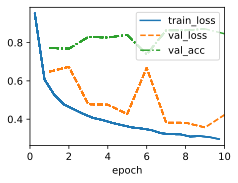

In [14]:
trainer = d2l.Trainer(max_epochs=10, num_gpus=1)
data = d2l.FashionMNIST(batch_size=128)
model = BNLeNetScratch(lr=0.1)
model.apply_init([next(iter(data.get_dataloader(True)))[0]], d2l.init_cnn)
trainer.fit(model, data)

Let's have a look at the scale parameter `gamma` and the shift parameter `beta` learned from the first batch normalization layer.

In [15]:
model.net[1].gamma.reshape((-1,)), model.net[1].beta.reshape((-1,))

(tensor([2.1551, 1.4080, 2.7745, 1.5993, 1.5742, 1.6265], device='cuda:0',
        grad_fn=<ViewBackward0>),
 tensor([ 1.1494,  0.5991,  1.6456,  0.5824, -0.9122,  0.5512], device='cuda:0',
        grad_fn=<ViewBackward0>))

### 8.5.5. Concise Implementation

Compared with the BatchNorm class, which we just defined ourselves, we can use the BatchNorm class defined in high-level APIs from the deep learning framework directly. The code looks virtually identical to our implementation above, except that we no longer need to provide additional arguments for it to get the dimensions right.

In [16]:
class BNLeNet(d2l.Classifier):
    def __init__(self, lr=0.1, num_classes=10):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(
            nn.LazyConv2d(6, kernel_size=5), nn.LazyBatchNorm2d(),
            nn.Sigmoid(), nn.AvgPool2d(kernel_size=2, stride=2),
            nn.LazyConv2d(16, kernel_size=5), nn.LazyBatchNorm2d(),
            nn.Sigmoid(), nn.AvgPool2d(kernel_size=2, stride=2),
            nn.Flatten(), nn.LazyLinear(120), nn.LazyBatchNorm1d(),
            nn.Sigmoid(), nn.LazyLinear(84), nn.LazyBatchNorm1d(),
            nn.Sigmoid(), nn.LazyLinear(num_classes))

Below, we use the same hyperparameters to train our model. Note that as usual, the high-level API variant runs much faster because its code has been compiled to C++ or CUDA while our custom implementation must be interpreted by Python.

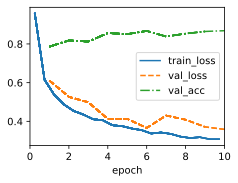

In [17]:
trainer = d2l.Trainer(max_epochs=10, num_gpus=1)
data = d2l.FashionMNIST(batch_size=128)
model = BNLeNet(lr=0.1)
model.apply_init([next(iter(data.get_dataloader(True)))[0]], d2l.init_cnn)
trainer.fit(model, data)

### 8.5.6. Discussion

Intuitively, batch normalization is thought to make the optimization landscape smoother. However, we must be careful to distinguish between speculative intuitions and true explanations for the phenomena that we observe when training deep models. Recall that we do not even know why simpler deep neural networks (MLPs and conventional CNNs) generalize well in the first place. Even with dropout and weight decay, they remain so flexible that their ability to generalize to unseen data likely needs significantly more refined learning-theoretic generalization guarantees.

The original paper proposing batch normalization (Ioffe and Szegedy, 2015), in addition to introducing a powerful and useful tool, offered an explanation for why it works: by reducing *internal covariate shift*. Presumably by *internal covariate shift* they meant something like the intuition expressed above---the notion that the distribution of variable values changes over the course of training. However, there were two problems with this explanation: i) This drift is very different from *covariate shift*, rendering the name a misnomer. If anything, it is closer to concept drift. ii) The explanation offers an under-specified intuition but leaves the question of *why precisely this technique works* an open question wanting for a rigorous explanation. Throughout this book, we aim to convey the intuitions that practitioners use to guide their development of deep neural networks. However, we believe that it is important to separate these guiding intuitions from established scientific fact. Eventually, when you master this material and start writing your own research papers you will want to be clear to delineate between technical claims and hunches.

Following the success of batch normalization, its explanation in terms of *internal covariate shift* has repeatedly surfaced in debates in the technical literature and broader discourse about how to present machine learning research. In a memorable speech given while accepting a Test of Time Award at the 2017 NeurIPS conference, Ali Rahimi used *internal covariate shift* as a focal point in an argument likening the modern practice of deep learning to alchemy. Subsequently, the example was revisited in detail in a position paper outlining troubling trends in machine learning (Lipton and Steinhardt, 2018). Other authors have proposed alternative explanations for the success of batch normalization, some (Santurkar et al., 2018) claiming that batch normalization's success comes despite exhibiting behavior that is in some ways opposite to those claimed in the original paper.

We note that the *internal covariate shift* is no more worthy of criticism than any of thousands of similarly vague claims made every year in the technical machine learning literature. Likely, its resonance as a focal point of these debates owes to its broad recognizability for the target audience. Batch normalization has proven an indispensable method, applied in nearly all deployed image classifiers, earning the paper that introduced the technique tens of thousands of citations. We conjecture, though, that the guiding principles of regularization through noise injection, acceleration through rescaling and lastly preprocessing may well lead to further inventions of layers and techniques in the future.

On a more practical note, there are a number of aspects worth remembering about batch normalization:

* During model training, batch normalization continuously adjusts the intermediate output of the network by utilizing the mean and standard deviation of the minibatch, so that the values of the intermediate output in each layer throughout the neural network are more stable.

* Batch normalization is slightly different for fully connected layers than for convolutional layers. In fact, for convolutional layers, layer normalization can sometimes be used as an alternative.

* Like a dropout layer, batch normalization layers have different behaviors in training mode than in prediction mode.

* Batch normalization is useful for regularization and improving convergence in optimization. By contrast, the original motivation of reducing internal covariate shift seems not to be a valid explanation.

* For more robust models that are less sensitive to input perturbations, consider removing batch normalization (Wang et al., 2022).

### 8.5.7. Exercises

1. Should we remove the bias parameter from the fully connected layer or the convolutional layer before the batch normalization? Why?

1. Compare the learning rates for LeNet with and without batch normalization.
  - Plot the increase in validation accuracy.
  - How large can you make the learning rate before the optimization fails in both cases?

1. Do we need batch normalization in every layer? Experiment with it.

1. Implement a "lite" version of batch normalization that only removes the mean, or alternatively one that only removes the variance. How does it behave?

1. Fix the parameters `beta` and `gamma`. Observe and analyze the results.

1. Can you replace dropout by batch normalization? How does the behavior change?

1. Research ideas: think of other normalization transforms that you can apply:
  - Can you apply the probability integral transform?
  - Can you use a full-rank covariance estimate? Why should you probably not do that?
  - Can you use other compact matrix variants (block-diagonal, low-displacement rank, Monarch, etc.)?
  - Does a sparsification compression act as a regularizer?
  - Are there other projections (e.g., convex cone, symmetry group-specific transforms) that you can use?

## 8.6. Residual Networks (ResNet) and ResNeXt

As we design ever deeper networks it becomes imperative to understand how adding layers can increase the complexity and expressiveness of the network. Even more important is the ability to design networks where adding layers makes networks strictly more expressive rather than just different. To make some progress we need a bit of mathematics.

In [18]:
import torch
from torch import nn
from torch.nn import functional as F
from d2l import torch as d2l

### 8.6.1. Function Classes

Consider $\mathcal{F}$, the class of functions that a specific network architecture (together with learning rates and other hyperparameter settings) can reach. That is, for all $f \in \mathcal{F}$ there exists some set of parameters (e.g., weights and biases) that can be obtained through training on a suitable dataset. Let's assume that $f^*$ is the "truth" function that we really would like to find. If it is in $\mathcal{F}$, we are in good shape but typically we will not be quite so lucky. Instead, we will try to find some $f^*_\mathcal{F}$ which is our best bet within $\mathcal{F}$. For instance, given a dataset with features $\mathbf{X}$ and labels $\mathbf{y}$, we might try finding it by solving the following optimization problem:

$$f^*_\mathcal{F} \stackrel{\textrm{def}}{=} \mathop{\mathrm{argmin}}_f L(\mathbf{X}, \mathbf{y}, f) \textrm{ subject to } f \in \mathcal{F}. \tag{8.6.1} $$

We know that regularization (Morozov, 1984, Tikhonov and Arsenin, 1977) may control complexity of $\mathcal{F}$ and achieve consistency, so a larger size of training data generally leads to better $f^*_\mathcal{F}$. It is only reasonable to assume that if we design a different and more powerful architecture $\mathcal{F}'$ we should arrive at a better outcome. In other words, we would expect that $f^*_{\mathcal{F}'}$ is "better" than $f^*_{\mathcal{F}}$. However, if $\mathcal{F} \not\subseteq \mathcal{F}'$ there is no guarantee that this should even happen. In fact, $f^*_{\mathcal{F}'}$ might well be worse. As illustrated by Fig. 8.6.1, for non-nested function classes, a larger function class does not always move closer to the "truth" function $f^*$. For instance, on the left of Fig. 8.6.1, though $\mathcal{F}_3$ is closer to $f^*$ than $\mathcal{F}_1$, $\mathcal{F}_6$ moves away and there is no guarantee that further increasing the complexity can reduce the distance from $f^*$. With nested function classes where $\mathcal{F}_1 \subseteq \cdots \subseteq \mathcal{F}_6$ on the right of Fig. 8.6.1, we can avoid the aforementioned issue from the non-nested function classes.

<p align="center">
  <img src="http://d2l.ai/_images/functionclasses.svg"/>
  <br />
  <em>Fig. 8.6.1</em> For non-nested function classes, a larger (indicated by area) function class does not guarantee we will get closer to the "truth" function ($\mathit{f}^*$). This does not happen in nested function classes.
</p>

Thus, *only if larger function classes contain the smaller ones are we guaranteed that increasing them strictly increases the expressive power of the network*. For deep neural networks, if we can train the newly-added layer into an identity function $f(\mathbf{x}) = \mathbf{x}$, the new model will be as effective as the original model. As the new model may get a better solution to fit the training dataset, the added layer might make it easier to reduce training errors.

This is the question that He et al. (2016) considered when working on very deep computer vision models. At the heart of their proposed *residual network* (*ResNet*) is the idea that every additional layer should more easily contain the identity function as one of its elements. These considerations are rather profound but they led to a surprisingly simple solution, a *residual block*. With it, ResNet won the ImageNet Large Scale Visual Recognition Challenge in 2015. The design had a profound influence on how to build deep neural networks. For instance, residual blocks have been added to recurrent networks (Kim et al., 2017, Prakash et al., 2016). Likewise, Transformers (Vaswani et al., 2017) use them to stack many layers of networks efficiently. It is also used in graph neural networks (Kipf and Welling, 2016) and, as a basic concept, it has been used extensively in computer vision (Redmon and Farhadi, 2018, Ren et al., 2015). Note that residual networks are predated by highway networks (Srivastava et al., 2015) that share some of the motivation, albeit without the elegant parametrization around the identity function.

---

这段文字深入探讨了**函数类**（function class），并引出了**残差网络**（ResNet），这是深度学习发展史上的一个里程碑式思想。下面我将逐层解读其核心要点：

**一、问题背景：我们能学到“真实函数”吗？**

- 设 $ f^* $ 是我们希望学习到的“真实”函数（即数据生成机制）。
- 实际上，我们受限于模型架构（如神经网络结构、超参数等），只能在某个**可实现的函数集合** $ \mathcal{F} $ 中寻找最优解。
- 如果 $ f^* \in \mathcal{F} $，那当然理想；但通常 $ f^* \notin \mathcal{F} $，所以我们退而求其次，找：
  $$
  f^*_{\mathcal{F}} = \arg\min_{f \in \mathcal{F}} L(\mathbf{X}, \mathbf{y}, f)
  $$
  即在 $ \mathcal{F} $ 中对训练数据拟合最好的函数。

> ✅ **关键点**：模型的好坏不仅取决于数据和优化算法，更根本地受限于它能表达的函数类 $ \mathcal{F} $。

**二、更大的函数类一定更好吗？不一定！**

- 直觉上，如果我们设计一个“更强大”的架构 $ \mathcal{F}' $，应该能得到更好的 $ f^*_{\mathcal{F}'} $。
- **但前提是**：$ \mathcal{F} \subseteq \mathcal{F}' $（即新函数类包含旧的）。
- 如果两个函数类**不嵌套**（non-nested），比如 $ \mathcal{F}_6 $ 和 $ \mathcal{F}_1 $ 没有包含关系，那么即使 $ \mathcal{F}_6 $ “更大”，它也可能离 $ f^* $ 更远（见图左）。
- 只有在**嵌套函数类**（nested）的情况下（如 $ \mathcal{F}_1 \subseteq \mathcal{F}_2 \subseteq \cdots $），增加模型容量才**保证不会变差**（至少可以退化回小模型）。

> ⚠️ **重要洞见**：  
> **“更大 ≠ 更好”**，除非新模型能**包含旧模型的所有能力**。否则，增加复杂度可能适得其反。

**三、如何确保“更大包含更小”？——让新增层能表示恒等映射**

- 对于深度神经网络，如果我们在已有模型上**增加一层**，但这一层能被训练成**恒等函数**（identity function）：
  $$
  f_{\text{new}}(\mathbf{x}) = f_{\text{old}}(\mathbf{x}) + \underbrace{0}_{\text{新增层输出}} = f_{\text{old}}(\mathbf{x})
  $$
  那么新模型至少不会比旧模型差。
- 更进一步，如果新增层能学到**有用的残差**（residual），即 $ f_{\text{new}}(\mathbf{x}) = f_{\text{old}}(\mathbf{x}) + \Delta(\mathbf{x}) $，就可能提升性能。

> 💡 这就是 ResNet 的核心思想：**不是直接学 $ H(\mathbf{x}) $，而是学残差 $ F(\mathbf{x}) = H(\mathbf{x}) - \mathbf{x} $**，然后输出 $ \mathbf{x} + F(\mathbf{x}) $。

**四、ResNet 的突破性贡献**

- He et al. (2016) 提出**残差块**（residual block），通过**跳跃连接**（skip connection）显式地让网络可以轻松实现恒等映射。
- 这使得训练**极深网络**（如 100+ 层）成为可能，解决了深度增加带来的**梯度消失/爆炸**和**退化问题**（degradation problem）。
- ResNet 在 2015 年 ImageNet 竞赛中大获成功，并迅速成为深度学习的基础构件。

**五、广泛影响**

- 残差思想已超越 CNN：
  - **RNN**：加入残差连接提升长序列建模能力；
  - **Transformer**：每个子层都有残差连接 + LayerNorm；
  - **GNN**：图神经网络也采用类似结构；
  - **目标检测**（YOLO, Faster R-CNN）等视觉模型普遍使用 ResNet 作为骨干网络。
- 虽然 Highway Networks（Srivastava et al., 2015）早先提出类似门控机制，但 ResNet 的**恒等映射设计更简洁、有效**，无需额外参数控制信息流。

**总结：核心思想提炼**

| 概念 | 含义 |
|------|------|
| **函数类 $ \mathcal{F} $** | 模型架构所能表达的所有函数集合 |
| **嵌套性**（Nestedness） | $ \mathcal{F}_1 \subseteq \mathcal{F}_2 \Rightarrow $ 增加容量不会变差 |
| **恒等映射可实现性** | 新增层能退化为“什么都不做”，是保证嵌套性的关键 |
| **残差学习** | 学 $ F(\mathbf{x}) = H(\mathbf{x}) - \mathbf{x} $，而非直接学 $ H(\mathbf{x}) $ |
| **工程意义** | 使超深网络可训练、性能更强、泛化更好 |

> 🌟 **一句话总结**：  
> **“让网络更容易退化为浅层，才能安全地构建深层。”**  
> —— 这就是 ResNet 的哲学。

### 8.6.2. Residual Blocks

Let's focus on a local part of a neural network, as depicted in Fig. 8.6.2. Denote the input by $\mathbf{x}$. We assume that $f(\mathbf{x})$, the desired underlying mapping we want to obtain by learning, is to be used as input to the activation function on the top. On the left, the portion within the dotted-line box must directly learn $f(\mathbf{x})$. On the right, the portion within the dotted-line box needs to learn the *residual mapping* $g(\mathbf{x}) = f(\mathbf{x}) - \mathbf{x}$, which is how the residual block derives its name. If the identity mapping $f(\mathbf{x}) = \mathbf{x}$ is the desired underlying mapping, the residual mapping amounts to $g(\mathbf{x}) = 0$ and it is thus easier to learn: we only need to push the weights and biases of the upper weight layer (e.g., fully connected layer and convolutional layer) within the dotted-line box to zero. The right figure illustrates the *residual block* of ResNet, where the solid line carrying the layer input $\mathbf{x}$ to the addition operator is called a ***residual connection*** (or *shortcut connection*). With residual blocks, inputs can forward propagate faster through the residual connections across layers. In fact, the residual block can be thought of as a special case of the multi-branch Inception block: it has two branches one of which is the identity mapping.

<p align="center">
  <img src="https://d2l.ai/_images/residual-block.svg"/>
  <br />
  <em>Fig. 8.6.2</em>
</p>

<em>Fig. 8.6.2</em> In a regular block (left), the portion within the dotted-line box must directly learn the mapping $\mathit{f}(\mathbf{x})$. In a residual block (right), the portion within the dotted-line box needs to learn the residual mapping $\mathit{g}(\mathbf{x}) = \mathit{f}(\mathbf{x}) - \mathbf{x}$, making the identity mapping $\mathit{f}(\mathbf{x}) = \mathbf{x}$ easier to learn.

ResNet has VGG's full $3\times 3$ convolutional layer design. The residual block has two $3\times 3$ convolutional layers with the same number of output channels. Each convolutional layer is followed by a batch normalization layer and a ReLU activation function. Then, we skip these two convolution operations and add the input directly before the final ReLU activation function. This kind of design requires that the output of the two convolutional layers has to be of the same shape as the input, so that they can be added together. If we want to change the number of channels, we need to introduce an additional $1\times 1$ convolutional layer to transform the input into the desired shape for the addition operation. Let's have a look at the code below.

In [22]:
class Residual(nn.Module):
    """The Residual block of ResNet models."""
    def __init__(self, num_channels, use_1x1conv=False, strides=1):
        super().__init__()
        self.conv1 = nn.LazyConv2d(num_channels, kernel_size=3, padding=1,
                                   stride=strides)
        self.conv2 = nn.LazyConv2d(num_channels, kernel_size=3, padding=1)
        if use_1x1conv:
            self.conv3 = nn.LazyConv2d(num_channels, kernel_size=1,
                                       stride=strides)
        else:
            self.conv3 = None
        self.bn1 = nn.LazyBatchNorm2d()
        self.bn2 = nn.LazyBatchNorm2d()

    def forward(self, X):
        Y = F.relu(self.bn1(self.conv1(X)))
        Y = self.bn2(self.conv2(Y))
        if self.conv3:
            X = self.conv3(X)
        Y += X
        return F.relu(Y)

This code generates two types of networks: one where we add the input to the output before applying the ReLU nonlinearity whenever `use_1x1conv=False`; and one where we adjust channels and resolution by means of a $1 \times 1$ convolution before adding. Fig. 8.6.3 illustrates this.

<p align="center">
  <img src="https://d2l.ai/_images/resnet-block.svg"/>
  <br />
  <em>Fig. 8.6.3</em>
</p>

<em>Fig. 8.6.3</em> ResNet block with and without $1 \times 1$ convolution, which transforms the input into the desired shape for the addition operation.

Now let's look at a situation where the input and output are of the same shape, where $1 \times 1$ convolution is not needed.

In [23]:
blk = Residual(3)
X = torch.randn(4, 3, 6, 6)
blk(X).shape

torch.Size([4, 3, 6, 6])

We also have the option to halve the output height and width while increasing the number of output channels. In this case we use $1 \times 1$ convolutions via `use_1x1conv=True`. This comes in handy at the beginning of each ResNet block to reduce the spatial dimensionality via `strides=2`.

In [24]:
blk = Residual(6, use_1x1conv=True, strides=2)
blk(X).shape

torch.Size([4, 6, 3, 3])

### 8.6.3. ResNet Model

The first two layers of ResNet are the same as those of the GoogLeNet we described before: the $7\times 7$ convolutional layer with 64 output channels and a stride of 2 is followed by the $3\times 3$ max-pooling layer with a stride of 2. The difference is the batch normalization layer added after each convolutional layer in ResNet.

In [25]:
class ResNet(d2l.Classifier):
    def b1(self):
        return nn.Sequential(
            nn.LazyConv2d(64, kernel_size=7, stride=2, padding=3),
            nn.LazyBatchNorm2d(), nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1))

GoogLeNet uses four modules made up of Inception blocks. However, ResNet uses four modules made up of residual blocks, each of which uses several residual blocks with the same number of output channels. The number of channels in the first module is the same as the number of input channels. Since a max-pooling layer with a stride of 2 has already been used, it is not necessary to reduce the height and width. In the first residual block for each of the subsequent modules, the number of channels is doubled compared with that of the previous module, and the height and width are halved.

In [26]:
@d2l.add_to_class(ResNet)
def block(self, num_residuals, num_channels, first_block=False):
    blk = []
    for i in range(num_residuals):
        if i == 0 and not first_block:
            blk.append(Residual(num_channels, use_1x1conv=True, strides=2))
        else:
            blk.append(Residual(num_channels))
    return nn.Sequential(*blk)

Then, we add all the modules to ResNet. Here, two residual blocks are used for each module. Lastly, just like GoogLeNet, we add a global average pooling layer, followed by the fully connected layer output.

In [27]:
@d2l.add_to_class(ResNet)
def __init__(self, arch, lr=0.1, num_classes=10):
    super(ResNet, self).__init__()
    self.save_hyperparameters()
    self.net = nn.Sequential(self.b1())
    for i, b in enumerate(arch):
        self.net.add_module(f'b{i+2}', self.block(*b, first_block=(i==0)))
    self.net.add_module('last', nn.Sequential(
        nn.AdaptiveAvgPool2d((1, 1)), nn.Flatten(),
        nn.LazyLinear(num_classes)))
    self.net.apply(d2l.init_cnn)

There are four convolutional layers in each module (excluding the $1\times 1$ convolutional layer). Together with the first $7\times 7$ convolutional layer and the final fully connected layer, there are 18 layers in total. Therefore, this model is commonly known as ResNet-18. By configuring different numbers of channels and residual blocks in the module, we can create different ResNet models, such as the deeper 152-layer ResNet-152. Although the main architecture of ResNet is similar to that of GoogLeNet, *ResNet's structure is simpler and easier to modify*. All these factors have resulted in the rapid and widespread use of ResNet. Fig. 8.6.4 depicts the full ResNet-18.

<p align="center">
  <img src="https://d2l.ai/_images/resnet18-90.svg"/>
  <br />
  <em>Fig. 8.6.4</em> The ResNet-18 architecture.
</p>

Before training ResNet, let's observe how the input shape changes across different modules in ResNet. As in all the previous architectures, the resolution decreases while the number of channels increases up until the point where a global average pooling layer aggregates all features.

In [28]:
class ResNet18(ResNet):
    def __init__(self, lr=0.1, num_classes=10):
        super().__init__(((2, 64), (2, 128), (2, 256), (2, 512)),
                       lr, num_classes)

ResNet18().layer_summary((1, 1, 96, 96))

Sequential output shape:	 torch.Size([1, 64, 24, 24])
Sequential output shape:	 torch.Size([1, 64, 24, 24])
Sequential output shape:	 torch.Size([1, 128, 12, 12])
Sequential output shape:	 torch.Size([1, 256, 6, 6])
Sequential output shape:	 torch.Size([1, 512, 3, 3])
Sequential output shape:	 torch.Size([1, 10])


### 8.6.4. Training

We train ResNet on the Fashion-MNIST dataset, just like before. ResNet is quite a powerful and flexible architecture. The plot capturing training and validation loss illustrates a significant gap between both graphs, with the training loss being considerably lower. For a network of this flexibility, more training data would offer distinct benefit in closing the gap and improving accuracy.

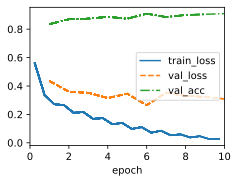

In [29]:
model = ResNet18(lr=0.01)
trainer = d2l.Trainer(max_epochs=10, num_gpus=1)
data = d2l.FashionMNIST(batch_size=128, resize=(96, 96))
model.apply_init([next(iter(data.get_dataloader(True)))[0]], d2l.init_cnn)
trainer.fit(model, data)

### 8.6.5. ResNeXt

One of the challenges one encounters in the design of ResNet is the trade-off between nonlinearity and dimensionality within a given block. That is, we could add more nonlinearity by increasing the number of layers, or by increasing the width of the convolutions. An alternative strategy is to increase the number of channels that can carry information between blocks. Unfortunately, the latter comes with a quadratic penalty since the computational cost of ingesting $c_\textrm{i}$ channels and emitting $c_\textrm{o}$ channels is proportional to $\mathcal{O}(c_\textrm{i} \cdot c_\textrm{o})$ (see our discussion in Section 7.4).

We can take some inspiration from the Inception block of Fig. 8.4.1 which has information flowing through the block in separate groups. Applying the idea of multiple independent groups to the ResNet block of Fig. 8.6.3 led to the design of ResNeXt (Xie et al., 2017). Different from the smorgasbord of transformations in Inception, ResNeXt adopts the *same* transformation in all branches, thus minimizing the need for manual tuning of each branch.

<p align="center">
  <img src="https://d2l.ai/_images/resnext-block.svg"/>
  <br />
  <em>Fig. 8.6.5</em>
</p>

<em>Fig. 8.6.5</em> The ResNeXt block. The use of grouped convolution with $\mathit{g}$ groups is $\mathit{g}$ times faster than a dense convolution. It is a bottleneck residual block when the number of intermediate channels $\mathit{b}$ is less than $\mathit{c}$.

Breaking up a convolution from $c_\textrm{i}$ to $c_\textrm{o}$ channels into one of $g$ groups of size $c_\textrm{i}/g$ generating $g$ outputs of size $c_\textrm{o}/g$ is called, quite fittingly, a ***grouped convolution***. The computational cost (proportionally) is reduced from $\mathcal{O}(c_\textrm{i} \cdot c_\textrm{o})$ to $\mathcal{O}(g \cdot (c_\textrm{i}/g) \cdot (c_\textrm{o}/g)) = \mathcal{O}(c_\textrm{i} \cdot c_\textrm{o} / g)$, i.e., it is $g$ times faster. Even better, the number of parameters needed to generate the output is also reduced from a $c_\textrm{i} \times c_\textrm{o}$ matrix to $g$ smaller matrices of size $(c_\textrm{i}/g) \times (c_\textrm{o}/g)$, again a $g$ times reduction. In what follows we assume that both $c_\textrm{i}$ and $c_\textrm{o}$ are divisible by $g$.

The only challenge in this design is that no information is exchanged between the $g$ groups. The ResNeXt block of Fig. 8.6.5 amends this in two ways: the grouped convolution with a $3 \times 3$ kernel is sandwiched in between two $1 \times 1$ convolutions. The second one serves double duty in changing the number of channels back. The benefit is that we only pay the $\mathcal{O}(c \cdot b)$ cost for $1 \times 1$ kernels and can make do with an $\mathcal{O}(b^2 / g)$ cost for $3 \times 3$ kernels. Similar to the residual block implementation in Section 8.6.2, the residual connection is replaced (thus generalized) by a $1 \times 1$ convolution.

The right-hand figure in Fig. 8.6.5 provides a much more concise summary of the resulting network block. It will also play a major role in the design of generic modern CNNs in Section 8.8. Note that the idea of grouped convolutions dates back to the implementation of AlexNet (Krizhevsky et al., 2012). When distributing the network across two GPUs with limited memory, the implementation treated each GPU as its own channel with no ill effects.

The following implementation of the `ResNeXtBlock` class takes as argument `groups` ($g$), with `bot_channels` ($b$) intermediate (bottleneck) channels. Lastly, when we need to reduce the height and width of the representation, we add a stride of $2$ by setting `use_1x1conv=True, strides=2`.

---

这段文字深入讲解了 **ResNeXt**（Residual Next）网络块的设计动机、核心思想和实现细节。

🧠 **背景与挑战**

> **原文**：One of the challenges one encounters in the design of ResNet is the trade-off between nonlinearity and dimensionality within a given block...

在设计 **ResNet** 时，一个关键挑战是在 **非线性能力**（nonlinearity）和 **维度/通道数**（dimensionality）之间做权衡：

- **增加非线性**：可以通过堆叠更多层（加深）或增加卷积核宽度（加宽）。
- **增加信息通道数**（即中间特征图的通道数）也能提升表达能力，但代价高昂——因为从 $c_{\mathrm{i}}$ 个输入通道到 $c_{\mathrm{o}}$ 个输出通道的卷积计算复杂度是 $\mathcal{O}(c_{\mathrm{i}} \cdot c_{\mathrm{o}})$，呈**二次增长**。

这引出了一个问题：**如何在不显著增加计算成本的前提下，提升模型容量？**

💡 **灵感来源：Inception 与分组思想**

> **原文**：We can take some inspiration from the Inception block... which has information flowing through the block in separate groups.

作者从 **Inception 模块**（如 Fig. 8.4.1）获得启发：**让信息在多个并行路径中流动**（即“分组”处理）。  
但 Inception 的问题是：每条路径使用**不同的操作**（如 $1 \times 1$、$3 \times 3$、$5 \times 5$ 卷积、池化等），需要大量人工调参。

而 **ResNeXt**（Xie et al., 2017）提出一个更简洁的策略：
> **所有分支使用完全相同的变换结构**（same transformation），从而避免手动设计每条路径。

这体现了“**聚合变换**”（aggregated transformations）的思想：不是靠复杂的异构结构，而是靠**多个相同但独立的子网络并行工作**来增强表达力。

🔧 **核心机制：分组卷积（Grouped Convolution）**

> **原文**：Breaking up a convolution... into one of $g$ groups... is called a *grouped convolution*.

**分组卷积**（Grouped Convolution）是 ResNeXt 的关键技术：

- 将输入通道 $c_{\mathrm{i}}$ 和输出通道 $c_{\mathrm{o}}$ 各自分成 $g$ 组。
- 每组内部进行独立的卷积：输入 $c_{\mathrm{i}}/g$ → 输出 $c_{\mathrm{o}}/g$。
- 总共 $g$ 个并行的小卷积，彼此**不交换信息**。

✅ **优势**：
- **计算量减少**：从 $\mathcal{O}(c_{\mathrm{i}} c_{\mathrm{o}})$ 降到 $\mathcal{O}(c_{\mathrm{i}} c_{\mathrm{o}} / g)$，**快 $g$ 倍**。
- **参数量减少**：同样减少 $g$ 倍。

⚠️ **问题**：
- 各组之间**没有信息交互**，可能导致表达能力受限。

🧩 **ResNeXt 块的完整结构**（Fig. 8.6.5）

为了解决“组间无通信”的问题，ResNeXt 块采用 **三明治结构**：

1. **第一个 $1 \times 1$ 卷积**：降维（bottleneck），将通道数从 $c$ 降到 $b$（$b < c$）。
2. **中间 $3 \times 3$ 分组卷积**（$g$ 组）：在低维空间中进行高效并行处理。
3. **第二个 $1 \times 1$ 卷积**：升维，恢复到原始通道数 $c$。

同时，**残差连接**（residual connection）依然存在：
- 如果输入输出尺寸不同（如 stride=2），则用一个 **$1 \times 1$ 卷积 + stride=2** 来匹配维度（类似 ResNet 的 projection shortcut）。

> 这种结构被称为 **bottleneck residual block with grouped convolutions**。

⚙️ **计算效率分析**

- **$1 \times 1$ 卷积**：计算量为 $\mathcal{O}(c \cdot b)$（两次：降维 + 升维）。
- **$3 \times 3$ 分组卷积**：计算量为 $\mathcal{O}(b^2 / g)$（因为每组处理 $b/g$ 通道）。

相比标准 ResNet bottleneck（$3 \times 3$ 卷积是 dense 的，计算量 $\mathcal{O}(b^2)$），**ResNeXt 在 $3 \times 3$ 阶段快了 $g$ 倍**。

📜 **实现要点（`ResNeXtBlock` 类）**

文中提到实现时需传入：
- `groups`（即 $g$）：分组数。
- `bot_channels`（即 $b$）：bottleneck 中间的通道数。
- 若需下采样（减小高宽），则设 `use_1x1conv=True, strides=2`，此时残差路径也用 $1 \times 1$ 卷积调整维度。

🕰️ **历史渊源**

> 分组卷积并非 ResNeXt 首创！早在 **AlexNet**（2012）中就因 GPU 内存限制，将网络拆到两个 GPU 上运行，**每个 GPU 处理一半通道**，本质上就是 $g=2$ 的分组卷积。

ResNeXt 的创新在于**系统性地将分组卷积作为提升模型容量的核心机制**，而非工程妥协。

✅ **总结：ResNeXt 的核心思想**

| 维度 | ResNet | ResNeXt |
|------|--------|--------|
| **结构** | 单一路径 | $g$ 个**相同**的并行路径 |
| **卷积类型** | 标准卷积 | **分组卷积**（中间 $3 \times 3$） |
| **设计哲学** | 加深/加宽 | **增加“基数”**（cardinality = $g$） |
| **目标** | 提升深度带来的性能 | 提升**并行路径数**带来的表达多样性 |

> ResNeXt 提出：**“基数”**（cardinality）——即变换的独立路径数——是比单纯增加深度或宽度更有效的提升模型性能的方式。

In [31]:
class ResNeXtBlock(nn.Module):
    """The ResNeXt block."""
    def __init__(self, num_channels, groups, bot_mul, use_1x1conv=False,
                 strides=1):
        super().__init__()
        bot_channels = int(round(num_channels * bot_mul))
        self.conv1 = nn.LazyConv2d(bot_channels, kernel_size=1, stride=1)
        self.conv2 = nn.LazyConv2d(bot_channels, kernel_size=3,
                                   stride=strides, padding=1,
                                   groups=bot_channels//groups)
        self.conv3 = nn.LazyConv2d(num_channels, kernel_size=1, stride=1)
        self.bn1 = nn.LazyBatchNorm2d()
        self.bn2 = nn.LazyBatchNorm2d()
        self.bn3 = nn.LazyBatchNorm2d()
        if use_1x1conv:
            self.conv4 = nn.LazyConv2d(num_channels, kernel_size=1, stride=strides)
            self.bn4 = nn.LazyBatchNorm2d()
        else:
            self.conv4 = None

    def forward(self, X):
        Y = F.relu(self.bn1(self.conv1(X)))
        Y = F.relu(self.bn2(self.conv2(Y)))
        Y = self.bn3(self.conv3(Y))
        if self.conv4:
            X = self.bn4(self.conv4(X))
        return F.relu(Y + X)

Its use is entirely analogous to that of the `ResNetBlock` discussed previously. For instance, when using (`use_1x1conv=False, strides=1`), the input and output are of the same shape. Alternatively, setting `use_1x1conv=True, strides=2` halves the output height and width.

In [32]:
blk = ResNeXtBlock(32, 16, 1)
X = torch.randn(4, 32, 96, 96)
blk(X).shape

torch.Size([4, 32, 96, 96])

### 8.6.6. Summary and Discussion

Nested function classes are desirable since they allow us to obtain strictly *more powerful* rather than also subtly *different* function classes when adding capacity. One way of accomplishing this is by letting additional layers to simply pass through the input to the output. Residual connections allow for this. *As a consequence, this changes the inductive bias from simple functions being of the form $f(\mathbf{x}) = 0$ to simple functions looking like $f(\mathbf{x}) = \mathbf{x}$*.

---
牧之：反映在实现上是如此简单，反映在认知上却是如此深刻！

The residual mapping can learn the identity function more easily, such as pushing parameters in the weight layer to zero. We can train an effective *deep* neural network by having residual blocks. Inputs can forward propagate faster through the residual connections across layers. As a consequence, we can thus train much deeper networks. For instance, the original ResNet paper (He et al., 2016) allowed for up to 152 layers. Another benefit of residual networks is that it allows us to add layers, initialized as the identity function, *during* the training process. After all, the default behavior of a layer is to let the data pass through unchanged. This can accelerate the training of very large networks in some cases.

Prior to residual connections, bypassing paths with gating units were introduced to effectively train highway networks with over 100 layers (Srivastava et al., 2015). Using identity functions as bypassing paths, ResNet performed remarkably well on multiple computer vision tasks. Residual connections had a major influence on the design of subsequent deep neural networks, of either convolutional or sequential nature. As we will introduce later, the Transformer architecture (Vaswani et al., 2017) adopts residual connections (together with other design choices) and is pervasive in areas as diverse as language, vision, speech, and reinforcement learning.

ResNeXt is an example for how the design of convolutional neural networks has evolved over time: by being more frugal with computation and trading it off against the size of the activations (number of channels), it allows for faster and more accurate networks at lower cost. An alternative way of viewing grouped convolutions is to think of a block-diagonal matrix for the convolutional weights. Note that there are quite a few such "tricks" that lead to more efficient networks. For instance, ShiftNet (Wu et al., 2018) mimicks the effects of a $3 \times 3$ convolution, simply by adding shifted activations to the channels, offering increased function complexity, this time without any computational cost.

A common feature of the designs we have discussed so far is that the network design is fairly manual, primarily relying on the ingenuity of the designer to find the "right" network hyperparameters. While clearly feasible, it is also very costly in terms of human time and there is no guarantee that the outcome is optimal in any sense. In Section 8.8 we will discuss a number of strategies for obtaining high quality networks in a more automated fashion. In particular, we will review the notion of *network design spaces* that led to the RegNetX/Y models (Radosavovic et al., 2020).

### 8.6.7. Exercises

1. What are the major differences between the Inception block in Fig. 8.4.1 and the residual block? How do they compare in terms of computation, accuracy, and the classes of functions they can describe?

1. Refer to Table 1 in the ResNet paper (He et al., 2016) to implement different variants of the network.

1. For deeper networks, ResNet introduces a “bottleneck” architecture to reduce model complexity. Try to implement it.

1. In subsequent versions of ResNet, the authors changed the “convolution, batch normalization, and activation” structure to the “batch normalization, activation, and convolution” structure. Make this improvement yourself. See Figure 1 in He et al. (2016) for details.

1. Why can’t we just increase the complexity of functions without bound, even if the function classes are nested?

## 8.7. Densely Connected Networks (DenseNet)

ResNet significantly changed the view of how to parametrize the functions in deep networks. *DenseNet* (dense convolutional network) is to some extent the logical extension of this (Huang et al., 2017). DenseNet is characterized by both the connectivity pattern where each layer connects to all the preceding layers and the concatenation operation (rather than the addition operator in ResNet) to preserve and reuse features from earlier layers. To understand how to arrive at it, let's take a small detour to mathematics.

In [33]:
import torch
from torch import nn
from d2l import torch as d2l

### 8.7.1. From ResNet to DenseNet

Recall the Taylor expansion for functions. At the point $x = 0$ it can be written as

$$f(x) = f(0) + x \cdot \left[f'(0) + x \cdot \left[\frac{f''(0)}{2!}  + x \cdot \left[\frac{f'''(0)}{3!}  + \cdots \right]\right]\right]. \tag{8.7.1}$$

The key point is that it decomposes a function into terms of increasingly higher order. In a similar vein, ResNet decomposes functions into

$$f(\mathbf{x}) = \mathbf{x} + g(\mathbf{x}). \tag{8.7.2}$$

That is, ResNet decomposes $f$ into a simple linear term and a more complex nonlinear one. What if we wanted to capture (not necessarily add) information beyond two terms? One such solution is DenseNet (Huang et al., 2017).

<p align="center">
  <img src="https://d2l.ai/_images/densenet-block.svg"/>
  <br />
  <em>Fig. 8.7.1</em> The main difference between ResNet (left) and DenseNet (right) in cross-layer connections: use of addition and use of concatenation.
</p>

As shown in Fig. 8.7.1, the key difference between ResNet and DenseNet is that in the latter case outputs are *concatenated* (denoted by $[,]$) rather than added. As a result, we perform a mapping from $\mathbf{x}$ to its values after applying an increasingly complex sequence of functions:

$$\mathbf{x} \to \left[
\mathbf{x},
f_1(\mathbf{x}),
f_2\left(\left[\mathbf{x}, f_1\left(\mathbf{x}\right)\right]\right), f_3\left(\left[\mathbf{x}, f_1\left(\mathbf{x}\right), f_2\left(\left[\mathbf{x}, f_1\left(\mathbf{x}\right)\right]\right)\right]\right), \ldots\right]. \tag{8.7.3}$$

In the end, all these functions are combined in MLP to reduce the number of features again. In terms of implementation this is quite simple:
rather than adding terms, we concatenate them. The name DenseNet arises from the fact that the dependency graph between variables becomes quite dense. The final layer of such a chain is densely connected to all previous layers. The dense connections are shown in Fig. 8.7.2.

<p align="center">
  <img src="http://d2l.ai/_images/densenet.svg"/>
  <br />
  <em>Fig. 8.7.2</em> Dense connections in DenseNet. Note how the dimensionality increases with depth.
</p>

---
牧之：再一次，反映在实现上是如此简单，反映在认知上却是如此深刻！一个可能的启示：如果一个“不起眼”的动作有用，那么，这里最大的发现不是这个动作，而是“不起眼”。它之所以不起眼，可能在于你没有真正理解它。

The main components that comprise a DenseNet are *dense blocks* and *transition layers*. The former define how the inputs and outputs are concatenated, while the latter control the number of channels so that it is not too large, since the expansion $\mathbf{x} \to \left[\mathbf{x}, f_1(\mathbf{x}), f_2\left(\left[\mathbf{x}, f_1\left(\mathbf{x}\right)\right]\right), \ldots \right]$ can be quite high-dimensional.

---

这段文字从**泰勒展开（Taylor expansion）**的视角出发，类比解释了深度学习中两种重要的网络结构：**ResNet** 和 **DenseNet** 的设计理念，并重点阐述了 DenseNet 的核心思想与实现机制。

1、**泰勒展开的启发**

泰勒展开在 $ x = 0 $（即麦克劳林展开）处将一个光滑函数 $ f(x) $ 分解为：
$$
f(x) = f(0) + x f'(0) + \frac{x^2}{2!} f''(0) + \frac{x^3}{3!} f'''(0) + \cdots
$$
文中将其重写为嵌套形式（公式 8.7.1）：
$$
f(x) = f(0) + x \cdot \left[ f'(0) + x \cdot \left( \frac{f''(0)}{2!} + x \cdot \left( \frac{f'''(0)}{3!} + \cdots \right) \right) \right]
$$

**关键点**：函数被分解为**逐阶递增复杂度**的项之和——常数项、一阶项、二阶项……每一项捕捉更高阶的局部信息。

> ✅ 这种“逐层叠加高阶信息”的思想，启发了深度神经网络中跨层连接的设计。

2、**ResNet 的类比：加法式分解**

ResNet 将网络映射 $ f(\mathbf{x}) $ 分解为：
$$
f(\mathbf{x}) = \mathbf{x} + g(\mathbf{x}) \tag{8.7.2}
$$

- $ \mathbf{x} $：恒等映射（identity mapping），相当于“零阶项”或基础信息。
- $ g(\mathbf{x}) $：残差函数（通常由几层卷积构成），相当于“高阶修正项”。

> 🔁 **本质**：通过**加法**将原始输入与非线性变换结果融合，使得网络更容易优化（缓解梯度消失）。

3、**DenseNet 的进阶：拼接式信息聚合**

如果想**超越两阶分解**（即不止保留输入和当前输出），怎么办？  
→ **DenseNet 提出用“拼接（concatenation）”代替“相加（addition）”**。

**核心思想**（公式 8.7.3）：

每一层的输入不仅来自前一层，而是**所有前面层的输出拼接在一起**：
$$
\mathbf{x} \to \left[
\mathbf{x},\ 
f_1(\mathbf{x}),\ 
f_2\big([\mathbf{x}, f_1(\mathbf{x})]\big),\ 
f_3\big([\mathbf{x}, f_1(\mathbf{x}), f_2([\mathbf{x}, f_1(\mathbf{x})])]\big),\ 
\ldots
\right]
$$

- 每个函数 $ f_k $ 的输入是**从初始输入到前一层所有输出的拼接**。
- 这形成了**密集连接（dense connectivity）**：第 $ L $ 层直接接收前面所有 $ L-1 $ 层的信息。

> 📌 **优势**：
> - **特征重用（feature reuse）**：浅层特征可直接传到深层，利于梯度流动和信息传播。
> - **参数效率高**：每层只需学习“增量特征”，而非完整表示。
> - **更强的正则化效果**：密集连接隐式地增强了模型泛化能力。

4、**DenseNet 的结构组成**

为控制维度爆炸（因不断拼接导致通道数激增），DenseNet 引入两个关键模块：

1) **Dense Block（密集块）**

- 在块内部，各层按上述方式密集连接。
- 每层通常是一个 **BN → ReLU → Conv** 的组合（称为“bottleneck layer”以减少计算量）。
- 假设每层输出 $ k $ 个通道（称为 **growth rate**），则第 $ n $ 层的输入通道数为：$ \text{input\_channels} + (n-1) \times k $。

2) **Transition Layer（过渡层）**

- 放在 dense block 之间，用于**降维**和**下采样**。
- 通常包含：
  - 1×1 卷积：减少通道数（例如压缩到一半）。
  - 2×2 平均池化：降低空间分辨率。

> ⚖️ **平衡**：dense block 增加表达能力，transition layer 控制计算和内存开销。

5、**图示说明**

- **图 8.7.1**：对比 ResNet（加法） vs DenseNet（拼接）。
- **图 8.7.2**：展示 DenseNet 中“每层都连接所有前层”的密集拓扑结构，且特征图维度随深度增加（直到 transition layer 压缩）。

**总结：DenseNet 的核心洞见**

> **不要只加残差，而要累积所有历史特征！**

通过**拼接而非相加**，DenseNet 实现了：
- 更丰富的特征传播路径，
- 更强的梯度流（缓解 vanishing gradient），
- 更高效的参数利用（小模型也能高性能）。

这正如泰勒展开中保留所有阶次项一样，DenseNet 试图在深度网络中**显式建模多阶特征交互**，从而获得更强的表示能力。

✅ **一句话概括**：  
**DenseNet 通过密集拼接跨层特征，实现了类似泰勒展开中“逐阶叠加高阶信息”的深度网络架构，显著提升了特征复用与模型效率。**

### 8.7.2. Dense Blocks

DenseNet uses the modified "batch normalization, activation, and convolution" structure of ResNet (see the exercise in Section 8.6). First, we implement this convolution block structure.

In [34]:
def conv_block(num_channels):
    return nn.Sequential(
        nn.LazyBatchNorm2d(), nn.ReLU(),
        nn.LazyConv2d(num_channels, kernel_size=3, padding=1))

A *dense block* consists of multiple convolution blocks, each using the same number of output channels. In the forward propagation, however, we concatenate the input and output of each convolution block on the channel dimension. Lazy evaluation allows us to adjust the dimensionality automatically.

In [35]:
class DenseBlock(nn.Module):
    def __init__(self, num_convs, num_channels):
        super(DenseBlock, self).__init__()
        layer = []
        for i in range(num_convs):
            layer.append(conv_block(num_channels))
        self.net = nn.Sequential(*layer)

    def forward(self, X):
        for blk in self.net:
            Y = blk(X)
            # Concatenate input and output of each block along the channels
            X = torch.cat((X, Y), dim=1)
        return X

In the following example, we define a `DenseBlock` instance with two convolution blocks of 10 output channels. When using an input with three channels, we will get an output with  $3 + 10 + 10=23$ channels. The number of convolution block channels controls the growth in the number of output channels relative to the number of input channels. This is also referred to as the *growth rate*.

In [36]:
blk = DenseBlock(2, 10)
X = torch.randn(4, 3, 8, 8)
Y = blk(X)
Y.shape

torch.Size([4, 23, 8, 8])

### 8.7.3. Transition Layers

Since each dense block will increase the number of channels, adding too many of them will lead to an excessively complex model. A *transition layer* is used to control the complexity of the model. It reduces the number of channels by using a $1\times 1$ convolution. Moreover, it halves the height and width via average pooling with a stride of 2.

In [37]:
def transition_block(num_channels):
    return nn.Sequential(
        nn.LazyBatchNorm2d(), nn.ReLU(),
        nn.LazyConv2d(num_channels, kernel_size=1),
        nn.AvgPool2d(kernel_size=2, stride=2))

Apply a transition layer with 10 channels to the output of the dense block in the previous example.  This reduces the number of output channels to 10, and halves the height and width.

In [38]:
blk = transition_block(10)
blk(Y).shape

torch.Size([4, 10, 4, 4])

### 8.7.4. DenseNet Model

Next, we will construct a DenseNet model. DenseNet first uses the same single convolutional layer and max-pooling layer as in ResNet.

In [39]:
class DenseNet(d2l.Classifier):
    def b1(self):
        return nn.Sequential(
            nn.LazyConv2d(64, kernel_size=7, stride=2, padding=3),
            nn.LazyBatchNorm2d(), nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1))

Then, similar to the four modules made up of residual blocks that ResNet uses, DenseNet uses four dense blocks. As with ResNet, we can set the number of convolutional layers used in each dense block. Here, we set it to 4, consistent with the ResNet-18 model in Section 8.6. Furthermore, we set the number of channels (i.e., growth rate) for the convolutional layers in the dense block to 32, so 128 channels will be added to each dense block.

In ResNet, the height and width are reduced between each module by a residual block with a stride of 2. Here, we use the transition layer to halve the height and width and halve the number of channels. Similar to ResNet, a global pooling layer and a fully connected layer are connected at the end to produce the output.

In [40]:
@d2l.add_to_class(DenseNet)
def __init__(self, num_channels=64, growth_rate=32, arch=(4, 4, 4, 4),
             lr=0.1, num_classes=10):
    super(DenseNet, self).__init__()
    self.save_hyperparameters()
    self.net = nn.Sequential(self.b1())
    for i, num_convs in enumerate(arch):
        self.net.add_module(f'dense_blk{i+1}', DenseBlock(num_convs,
                                                          growth_rate))
        # The number of output channels in the previous dense block
        num_channels += num_convs * growth_rate
        # A transition layer that halves the number of channels is added
        # between the dense blocks
        if i != len(arch) - 1:
            num_channels //= 2
            self.net.add_module(f'tran_blk{i+1}', transition_block(
                num_channels))
    self.net.add_module('last', nn.Sequential(
        nn.LazyBatchNorm2d(), nn.ReLU(),
        nn.AdaptiveAvgPool2d((1, 1)), nn.Flatten(),
        nn.LazyLinear(num_classes)))
    self.net.apply(d2l.init_cnn)

### 8.7.5. Training

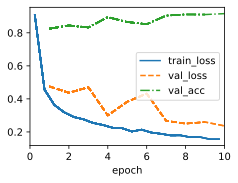

In [41]:
model = DenseNet(lr=0.01)
trainer = d2l.Trainer(max_epochs=10, num_gpus=1)
data = d2l.FashionMNIST(batch_size=128, resize=(96, 96))
trainer.fit(model, data)

### 8.7.6. Summary and Discussion

The main components that comprise DenseNet are dense blocks and transition layers. For the latter, we need to keep the dimensionality under control when composing the network by adding transition layers that shrink the number of channels again. In terms of cross-layer connections, in contrast to ResNet, where inputs and outputs are added together, DenseNet concatenates inputs and outputs on the channel dimension. Although these concatenation operations reuse features to achieve computational efficiency, unfortunately they lead to heavy GPU memory consumption. As a result, applying DenseNet may require more memory-efficient implementations that may increase training time (Pleiss et al., 2017).

### 8.7.7. Exercises

1. Why do we use average pooling rather than max-pooling in the transition layer?

1. One of the advantages mentioned in the DenseNet paper is that its model parameters are smaller than those of ResNet. Why is this the case?

1. One problem for which DenseNet has been criticized is its high memory consumption.
    - Is this really the case? Try to change the input shape to $224 \times 224$  to compare the actual GPU memory consumption empirically.
    - Can you think of an alternative means of reducing the memory consumption? How would you need to change the framework?

1. Implement the various DenseNet versions presented in Table 1 of the DenseNet paper (Huang et al., 2017).

1. Design an MLP-based model by applying the DenseNet idea. Apply it to the housing price prediction task in Section 5.7.

## 8.8. Designing Convolution Network Architectures

The previous sections have taken us on a tour of modern network design for computer vision. Common to all the work we covered was that it greatly relied on the intuition of scientists. Many of the architectures are heavily informed by human creativity and to a much lesser extent by systematic exploration of the design space that deep networks offer. Nonetheless, this *network engineering* approach has been tremendously successful.

Ever since AlexNet (Section 8.1) beat conventional computer vision models on ImageNet, it has become popular to construct very deep networks by stacking blocks of convolutions, all designed according to the same pattern. In particular, $3 \times 3$ convolutions were popularized by VGG networks (Section 8.2). NiN (Section 8.3) showed that even $1 \times 1$ convolutions could be beneficial by adding local nonlinearities. Moreover, NiN solved the problem of aggregating information at the head of a network by aggregating across all locations. GoogLeNet (Section 8.4) added multiple branches of different convolution width, combining the advantages of VGG and NiN in its Inception block. ResNets (Section 8.6) changed the inductive bias towards the identity mapping (from $f(x) = 0$). This allowed for very deep networks. Almost a decade later, the ResNet design is still popular, a testament to its design. Lastly, ResNeXt (Section 8.6.5) added grouped convolutions, offering a better trade-off between parameters and computation. A precursor to Transformers for vision, the Squeeze-and-Excitation Networks (SENets) allow for efficient information transfer between locations (Hu et al., 2018). This was accomplished by computing a per-channel global attention function.

Up to now we have omitted networks obtained via *neural architecture search* (NAS) (Liu et al., 2018, Zoph and Le, 2016). We chose to do so since their cost is usually enormous, relying on brute-force search, genetic algorithms, reinforcement learning, or some other form of hyperparameter optimization. Given a fixed search space, NAS uses a search strategy to automatically select an architecture based on the returned performance estimation. The outcome of NAS is a single network instance. EfficientNets are a notable outcome of this search (Tan and Le, 2019).

In the following we discuss an idea that is quite different to the quest for the *single best network*. It is computationally relatively inexpensive, it leads to scientific insights on the way, and it is quite effective in terms of the quality of outcomes. Let's review the strategy by Radosavovic et al. (2020) to *design network design spaces*. The strategy combines the strength of manual design and NAS. It accomplishes this by operating on *distributions of networks* and optimizing the distributions in a way to obtain good performance for entire families of networks. The outcome of it are *RegNets*, specifically RegNetX and RegNetY, plus a range of guiding principles for the design of performant CNNs.

In [42]:
from torch import nn
from d2l import torch as d2l

### 8.8.1. The AnyNet Design Space

The description below closely follows the reasoning in Radosavovic et al. (2020) with some abbreviations to make it fit in the scope of the book. To begin, we need a template for the family of networks to explore. One of the commonalities of the designs in this chapter is that the networks consist of a *stem*, a *body* and a *head*. The stem performs initial image processing, often through convolutions with a larger window size. The body consists of multiple blocks, carrying out the bulk of the transformations needed to go from raw images to object representations. Lastly, the head converts this into the desired outputs, such as via a softmax regressor for multiclass classification. The body, in turn, consists of multiple stages, operating on the image at decreasing resolutions. In fact, both the stem and each subsequent stage quarter the spatial resolution. Lastly, each stage consists of one or more blocks. This pattern is common to all networks, from VGG to ResNeXt. Indeed, for the design of generic AnyNet networks, Radosavovic et al. (2020) used the ResNeXt block of Fig. 8.6.5.

<p align="center">
  <img src="http://d2l.ai/_images/anynet.svg"/>
  <br />
  <em>Fig. 8.8.1</em>
</p>

  <em>Fig. 8.8.1</em> The AnyNet design space. The numbers $(\mathit{c}, \mathit{r})$ along each arrow indicate the number of channels $c$ and the resolution $\mathit{r} \times \mathit{r}$ of the images at that point. From left to right: generic network structure composed of stem, body, and head; body composed of four stages; detailed structure of a stage; two alternative structures for blocks, one without downsampling and one that halves the resolution in each dimension. Design choices include depth $\mathit{d_i}$, the number of output channels $\mathit{c_i}$, the number of groups $\mathit{g_i}$, and bottleneck ratio $\mathit{k_i}$ for any stage $\mathit{i}$.

Let’s review the structure outlined in Fig. 8.8.1 in detail. As mentioned, an AnyNet consists of a stem, body, and head. The stem takes as its input RGB images (3 channels), using a $3 \times 3$ convolution with a stride of $2$, followed by a batch norm, to halve the resolution from $r \times r$ to $r/2 \times r/2$. Moreover, it generates $c_0$ channels that serve as input to the body.

Since the network is designed to work well with ImageNet images of shape $224 \times 224 \times 3$, the body serves to reduce this to $7 \times 7 \times c_4$ through 4 stages (recall that $224 / 2^{1+4} = 7$), each with an eventual stride of $2$. Lastly, the head employs an entirely standard design via global average pooling, similar to NiN (Section 8.3), followed by a fully connected layer to emit an $n$-dimensional vector for $n$-class classification.

Most of the relevant design decisions are inherent to the body of the network. It proceeds in stages, where each stage is composed of the same type of ResNeXt blocks as we discussed in Section 8.6.5. The design there is again entirely generic: we begin with a block that halves the resolution by using a stride of $2$ (the rightmost in Fig. 8.8.1). To match this, the residual branch of the ResNeXt block needs to pass through a $1 \times 1$ convolution. This block is followed by a variable number of additional ResNeXt blocks that leave both resolution and the number of channels unchanged. Note that a common design practice is to add a slight bottleneck in the design of convolutional blocks. As such, with bottleneck ratio $k_i \geq 1$ we afford some number of channels, $c_i/k_i$,  within each block for stage $i$ (as the experiments show, this is not really effective and should be skipped). Lastly, since we are dealing with ResNeXt blocks, we also need to pick the number of groups $g_i$ for grouped convolutions at stage $i$.

This seemingly generic design space provides us nonetheless with many parameters: we can set the block width (number of channels) $c_0, \ldots c_4$, the depth (number of blocks) per stage $d_1, \ldots d_4$, the bottleneck ratios $k_1, \ldots k_4$, and the group widths (numbers of groups) $g_1, \ldots g_4$. In total this adds up to 17 parameters, resulting in an unreasonably large number of configurations that would warrant exploring. We need some tools to reduce this huge design space effectively. This is where the conceptual beauty of design spaces comes in. Before we do so, let's implement the generic design first.

---

这段文字是对 **AnyNet** 网络设计空间（design space）的详细解读，主要基于 Radosavovic 等人在 2020 年提出的框架。其核心思想是：**将现代卷积神经网络（如 ResNet、ResNeXt、RegNet 等）抽象为一个统一的、参数化的结构模板**，从而系统地探索哪些设计选择真正有效。

一、整体网络结构：**Stem–Body–Head 范式**

几乎所有现代 CNN 都可分解为三个部分：

1. **Stem（主干/起始层）**  
   - 输入：RGB 图像（3 通道，如 $224 \times 224 \times 3$）
   - 操作：通常是一个 stride=2 的 $3 \times 3$ 卷积 + BatchNorm
   - 输出：分辨率减半（$\to 112 \times 112$），通道数变为 $c_0$
   - 作用：初步提取低级特征，快速降低空间维度

2. **Body（主体）**  
   - 核心部分，包含多个 **Stage（阶段）**
   - 每个 Stage 进一步下采样（总共有 4 个 Stage）
   - 每个 Stage 由若干 **Block（块）** 组成（通常是 ResNeXt 块）
   - 总体效果：从 $112 \times 112 \to 56 \to 28 \to 14 \to 7$（共再降 4 次，每次 $\times \frac{1}{2}$，总降 $2^5 = 32$ 倍，$224 / 32 = 7$）

3. **Head（头部）**  
   - 全局平均池化（Global Average Pooling, GAP）$\to$ 将 $7 \times 7 \times c_4$ 变成 $1 \times 1 \times c_4$
   - 接一个全连接层（FC）$\to$ 输出 $n$ 维向量（$n$ 为类别数）
   - 类似 NiN（Network in Network）的设计

> ✅ **关键点**：这种“stem-body-head”结构是通用模板，适用于 VGG、ResNet、ResNeXt、EfficientNet 等。

二、**Body 的内部结构**：Stage 与 Block

- **每个 Stage $i$（$i=1\sim4$）包含**：
  - **第一个 Block**：带 **下采样（stride=2）**，用于将分辨率减半
    - 为保持残差连接，需在 shortcut 分支加 $1 \times 1$ 卷积（调整通道数和尺寸）
  - **后续 $d_i - 1$ 个 Block**：**无下采样**，保持分辨率和通道数不变
- 所有 Block 均基于 **ResNeXt 块**（见图 8.6.5），即：
  - 使用分组卷积（grouped convolution）
  - 可选瓶颈结构（bottleneck）

三、**每个 Stage 的可调超参数**（设计自由度）

对每个 Stage $i$，有 4 个关键设计参数：

| 参数 | 含义 | 符号 |
|------|------|------|
| **深度** | 该 Stage 中 Block 的数量 | $d_i$ |
| **宽度** | 输出通道数（特征图通道） | $c_i$ |
| **分组数** | 分组卷积中的组数（影响模型容量与计算效率） | $g_i$ |
| **瓶颈比** | 瓶颈层压缩比例（若使用 bottleneck） | $k_i \geq 1$ |

> 💡 注：瓶颈结构中，中间层通道数为 $c_i / k_i$。但文中指出：“as the experiments show, this is not really effective and should be skipped”——说明在 AnyNet 实验中，**瓶颈结构反而无效，建议去掉**。

四、**参数总量与设计空间爆炸问题**

- 总共 4 个 Stage $\to$ 每个 Stage 有 4 个参数（$d, c, g, k$）
- 加上 stem 的初始通道 $c_0$
- **总计：1（$c_0$）+ $4 \times 4 = 17$ 个自由参数**
- 若每个参数有 10 种可能取值 $\to$ 总组合数 $\approx 10^{17}$，**无法穷举**

➡️ 因此，**不能暴力搜索**，必须引入**设计空间简化策略**（如 RegNet 中发现的规律：通道数随 stage 指数增长、深度与宽度相关等）

五、图 8.8.1 的解读（**AnyNet 设计空间示意图**）

- 左到右展示层次结构：
  1. 整体：Stem $\to$ Body（4 stages）$\to$ Head
  2. Body 展开：4 个 Stage，每个输出 $(c_i, r_i)$
  3. 单个 Stage：由多个 Block 构成
  4. Block 两种形式：
     - **无下采样 Block**：输入输出尺寸相同
     - **带下采样 Block**：stride=2，shortcut 用 $1 \times 1$ 卷积匹配

- 图中标注 $(c, r)$ 表示当前特征图的 **通道数 $c$** 和 **分辨率 $r \times r$**

六、**总结与意义**

- **AnyNet 是一个“元架构”**：它不是具体模型，而是一个**生成模型的规则集合**
- 目标：通过系统实验（如随机采样 + 训练评估），**发现高效网络的共性规律**
- 后续工作（如 **RegNet**）正是基于 AnyNet 设计空间，通过数据分析提炼出简洁高效的网络生成规则（如线性对数通道增长、固定 stage 深度比等）

> 🔑 **核心思想**：与其手动设计网络，不如定义一个合理的搜索空间，用数据驱动的方式找出最优结构模式。

In [43]:
class AnyNet(d2l.Classifier):
    def stem(self, num_channels):
        return nn.Sequential(
            nn.LazyConv2d(num_channels, kernel_size=3, stride=2, padding=1),
            nn.LazyBatchNorm2d(), nn.ReLU())

Each stage consists of `depth` ResNeXt blocks, where `num_channels` specifies the block width. Note that the first block halves the height and width of input images.

In [44]:
@d2l.add_to_class(AnyNet)
def stage(self, depth, num_channels, groups, bot_mul):
    blk = []
    for i in range(depth):
        if i == 0:
            blk.append(d2l.ResNeXtBlock(num_channels, groups, bot_mul,
                use_1x1conv=True, strides=2))
        else:
            blk.append(d2l.ResNeXtBlock(num_channels, groups, bot_mul))
    return nn.Sequential(*blk)

Putting the network stem, body, and head together, we complete the implementation of AnyNet.

In [45]:
@d2l.add_to_class(AnyNet)
def __init__(self, arch, stem_channels, lr=0.1, num_classes=10):
    super(AnyNet, self).__init__()
    self.save_hyperparameters()
    self.net = nn.Sequential(self.stem(stem_channels))
    for i, s in enumerate(arch):
        self.net.add_module(f'stage{i+1}', self.stage(*s))
    self.net.add_module('head', nn.Sequential(
        nn.AdaptiveAvgPool2d((1, 1)), nn.Flatten(),
        nn.LazyLinear(num_classes)))
    self.net.apply(d2l.init_cnn)

### 8.8.2. Distributions and Parameters of Design Spaces

As just discussed in Section 8.8.1, parameters of a design space are hyperparameters of networks in that design space. Consider the problem of identifying good parameters in the AnyNet design space. We could try finding the *single best* parameter choice for a given amount of computation (e.g., FLOPs and compute time). If we allowed for even only *two* possible choices for each parameter, we would have to explore $2^{17} = 131072$ combinations to find the best solution. This is clearly infeasible because of its exorbitant cost. Even worse, we do not really learn anything from this exercise in terms of how one should design a network. Next time we add, say, an X-stage, or a shift operation, or similar, we would need to start from scratch. Even worse, due to the stochasticity in training (rounding, shuffling, bit errors), no two runs are likely to produce exactly the same results. A better strategy would be to try to determine general guidelines of how the choices of parameters should be related. For instance, the bottleneck ratio, the number of channels, blocks, groups, or their change between layers should ideally be governed by a collection of simple rules. The approach in Radosavovic et al. (2019) relies on the following four assumptions:

1. We assume that general design principles actually exist, so that many networks satisfying these requirements should offer good performance. Consequently, identifying a *distribution* over networks can be a sensible strategy. In other words, we assume that there are many good needles in the haystack.

1. We need not train networks to convergence before we can assess whether a network is good. Instead, it is sufficient to use the intermediate results as reliable guidance for final accuracy. Using (approximate) proxies to optimize an objective is referred to as multi-fidelity optimization (Forrester et al., 2007). Consequently, design optimization is carried out, based on the accuracy achieved after only a few passes through the dataset, reducing the cost significantly.

1. Results obtained at a smaller scale (for smaller networks) generalize to larger ones. Consequently, optimization is carried out for networks that are structurally similar, but with a smaller number of blocks, fewer channels, etc. Only in the end will we need to verify that the so-found networks also offer good performance at scale.

1. Aspects of the design can be approximately factorized so that it is possible to infer their effect on the quality of the outcome somewhat independently. In other words, the optimization problem is moderately easy.

These assumptions allow us to test many networks cheaply. In particular, we can *sample* uniformly from the space of configurations and evaluate their performance. Subsequently, we can evaluate the quality of the choice of parameters by reviewing the *distribution* of error/accuracy that can be achieved with said networks. Denote by $F(e)$ the cumulative distribution function (CDF) for errors committed by networks of a given design space, drawn using probability disribution $p$. That is,

$$F(e, p) \stackrel{\textrm{def}}{=} P_{\textrm{net} \sim p} \{e(\textrm{net}) \leq e\}. \tag{8.8.1}$$

Our goal is now to find a distribution $p$ over *networks* such that most networks have a very low error rate and where the support of $p$ is concise. Of course, this is computationally infeasible to perform accurately. We resort to a sample of networks $\mathcal{Z} \stackrel{\textrm{def}}{=} \{\textrm{net}_1, \ldots \textrm{net}_n\}$ (with errors $e_1, \ldots, e_n$, respectively) from $p$ and use the empirical CDF $\hat{F}(e, \mathcal{Z})$ instead:

$$\hat{F}(e, \mathcal{Z}) = \frac{1}{n}\sum_{i=1}^n \mathbf{1}(e_i \leq e). \tag{8.8.2}$$

Whenever the CDF for one set of choices majorizes (or matches) another CDF it follows that its choice of parameters is superior (or indifferent). Accordingly Radosavovic et al. (2020) experimented with a shared network bottleneck ratio $k_i = k$ for all stages $i$ of the network. This gets rid of three of the four parameters governing the bottleneck ratio. To assess whether this (negatively) affects the performance one can draw networks from the constrained and from the unconstrained distribution and compare the corresonding CDFs. It turns out that this constraint does not affect the accuracy of the distribution of networks at all, as can be seen in the first panel of Fig. 8.8.2. Likewise, we could choose to pick the same group width $g_i = g$ occurring at the various stages of the network. Again, this does not affect performance, as can be seen in the second panel of Fig. 8.8.2. Both steps combined reduce the number of free parameters by six.

<p align="center">
  <img src="https://d2l.ai/_images/regnet-fig.png"/>
  <br />
  <em>Fig. 8.8.2</em>
</p>

<em>Fig. 8.8.2</em> Comparing error empirical distribution functions of design spaces. $\textrm{AnyNet}_\mathit{A}$ is the original design space; $\textrm{AnyNet}_\mathit{B}$ ties the bottleneck ratios, $\textrm{AnyNet}_\mathit{C}$ also ties group widths, $\textrm{AnyNet}_\mathit{D}$ increases the network depth across stages. From left to right: (i) tying bottleneck ratios has no effect on performance; (ii) tying group widths has no effect on performance; (iii) increasing network widths (channels) across stages improves performance; (iv) increasing network depths across stages improves performance. Figure courtesy of Radosavovic et al. (2020).

Next we look for ways to reduce the multitude of potential choices for width and depth of the stages. It is a reasonable assumption that, as we go deeper, the number of channels should increase, i.e., $c_i \geq c_{i-1}$ ($w_{i+1} \geq w_i$ per their notation in Fig. 8.8.2), yielding $\textrm{AnyNetX}_D$. Likewise, it is equally reasonable to assume that as the stages progress, they should become deeper, i.e., $d_i \geq d_{i-1}$, yielding $\textrm{AnyNetX}_E$. This can be experimentally verified in the third and fourth panel of Fig. 8.8.2, respectively.

### 8.8.3. RegNet

The resulting $\textrm{AnyNetX}_E$ design space consists of simple networks
following easy-to-interpret design principles:

* Share the bottleneck ratio $k_i = k$ for all stages $i$;
* Share the group width $g_i = g$ for all stages $i$;
* Increase network width across stages: $c_{i} \leq c_{i+1}$;
* Increase network depth across stages: $d_{i} \leq d_{i+1}$.

This leaves us with a final set of choices: how to pick the specific values for the above parameters of the eventual $\textrm{AnyNetX}_E$ design space. By studying the best-performing networks from the distribution in $\textrm{AnyNetX}_E$ one can observe the following: the width of the network ideally increases linearly with the block index across the network, i.e., $c_j \approx c_0 + c_a j$, where $j$ is the block index and slope $c_a > 0$. Given that we get to choose a different block width only per stage, we arrive at a piecewise constant function, engineered to match this dependence. Furthermore, experiments also show that a bottleneck ratio of $k = 1$ performs best, i.e., we are advised not to use bottlenecks at all.

We recommend the interested reader reviews further details in the design of specific networks for different amounts of computation by perusing Radosavovic et al. (2020). For instance, an effective 32-layer RegNetX variant is given by $k = 1$ (no bottleneck), $g = 16$ (group width is 16), $c_1 = 32$ and $c_2 = 80$ channels for the first and second stage, respectively, chosen to be $d_1=4$ and $d_2=6$ blocks deep. The astonishing insight from the design is that it still applies, even when investigating networks at a larger scale. Even better, it even holds for Squeeze-and-Excitation (SE) network designs (RegNetY) that have a global channel activation (Hu et al., 2018).

In [ ]:
class RegNetX32(AnyNet):
    def __init__(self, lr=0.1, num_classes=10):
        stem_channels, groups, bot_mul = 32, 16, 1
        depths, channels = (4, 6), (32, 80)
        super().__init__(
            ((depths[0], channels[0], groups, bot_mul),
             (depths[1], channels[1], groups, bot_mul)),
            stem_channels, lr, num_classes)

We can see that each RegNetX stage progressively reduces resolution and increases output channels.

In [ ]:
RegNetX32().layer_summary((1, 1, 96, 96))

### 8.8.4. Training

Training the 32-layer RegNetX on the Fashion-MNIST dataset is just like before.

In [ ]:
model = RegNetX32(lr=0.05)
trainer = d2l.Trainer(max_epochs=10, num_gpus=1)
data = d2l.FashionMNIST(batch_size=128, resize=(96, 96))
trainer.fit(model, data)

### 8.8.5. Discussion

With desirable inductive biases (assumptions or preferences) like locality and translation invariance (Section 7.1) for vision, CNNs have been the dominant architectures in this area. This remained the case from LeNet up until Transformers (Section 11.7) (Dosovitskiy et al., 2021, Touvron et al., 2021) started surpassing CNNs in terms of accuracy. While much of the recent progress in terms of vision Transformers *can* be backported into CNNs (Liu et al., 2022), it is only possible at a higher computational cost. Just as importantly, recent hardware optimizations (NVIDIA Ampere and Hopper) have only widened the gap in favor of Transformers.

It is worth noting that Transformers have a significantly lower degree of inductive bias towards locality and translation invariance than CNNs. That learned structures prevailed is due, not least, to the availability of large image collections, such as LAION-400m and LAION-5B (Schuhmann et al., 2022) with up to 5 billion images. Quite surprisingly, some of the more relevant work in this context even includes MLPs (Tolstikhin et al., 2021).

In sum, vision Transformers (Section 11.8) by now lead in terms of state-of-the-art performance in large-scale image classification, showing that *scalability trumps inductive biases* (Dosovitskiy et al., 2021). This includes pretraining large-scale Transformers (Section 11.9) with multi-head self-attention (Section 11.5). We invite the readers to dive into these chapters for a much more detailed discussion.

---

牧之：整体趋势，将越来越多之前人工设计的固定东西变为可学习的内容。

### 8.8.6. Exercises

1. Increase the number of stages to four. Can you design a deeper RegNetX that performs better?

1. De-ResNeXt-ify RegNets by replacing the ResNeXt block with the ResNet block. How does your new model perform?

1. Implement multiple instances of a "VioNet" family by *violating* the design principles of RegNetX. How do they perform? Which of ($d_i$, $c_i$, $g_i$, $b_i$) is the most important factor?

1. Your goal is to design the "perfect" MLP. Can you use the design principles introduced above to find good architectures? Is it possible to extrapolate from small to large networks?